## 0. Group Info
**GROUP 1**
- A0296697Y HE Wei
- A0297466J HUANG Wenjie
- A0296660U JI Xiangtian
- A0296622X SU Hao
- A0221781J YANG Zikun

## 1. Introduction


This study aims to explore the potential relationship between vehicle distribution and air quality in Singapore through a data-driven approach, with a comparative analysis involving another city. **First, we propose the hypothesis that higher concentrations of private vehicles are positively correlated with increased levels of air pollution.** This means that in areas where private vehicles are more concentrated, pollutants such as PM2.5 and CO2 may be present at higher levels. **Secondly, we hypothesize that areas with higher traffic congestion exhibit poorer air quality.** By analyzing traffic flow and air quality data, we aim to uncover the impact of congestion on pollution and explore potential measures to improve this situation.


In [1]:
# required modules and packages
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import json
from collections import defaultdict
import seaborn as sns
import ast
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import requests
import json
import time
import os

## 2. Data collection & Preprocessing

### 2.1 Data collection
In this study, we used three main types of data: vehicle distribution data, traffic flow data and air pollution data, to explore the relationship between vehicle distribution, traffic congestion, and air quality in Singapore.

**Vehicle Distribution Data**: We downloaded the relevant CSV files directly from the official website.


**Traffic Flow Data**: We obtained real-time traffic flow data through the TrafficSpeedBands API provided by the Land Transport Authority (LTA) of Singapore. This dataset provides information on traffic speeds across road segments, which helps us analyze congestion levels in different areas. Using Python scripts, we accessed the API with an AccountKey in the request headers, regularly fetched the latest data, and stored it as JSON files to ensure the data's timeliness and completeness.

**Air Pollution Data**: Air quality data was obtained from the Pollutant Standards Index (PSI) API provided by the National Environment Agency (NEA) of Singapore. This dataset includes the concentrations of key pollutants such as PM2.5, PM10, and CO2 across different regions. Similar to the traffic flow data, we used Python scripts to regularly fetch the latest data and save it to local files for subsequent analysis. Also, historical data from 2017 is also obtained for further exploration.

In [ ]:
def fetch_traffic_data():
    url = "https://datamall2.mytransport.sg/ltaodataservice/v3/TrafficSpeedBands"
    headers = {
        'AccountKey': 'l9hZP/8WSwKzxAogbnA++w==', # personal key
        'accept': 'application/json'
    }
    
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        data = response.json()
        last_updated_time = data.get('lastUpdatedTime', 'unknown_time')
        os.makedirs('tf', exist_ok=True)
        with open(f'tf/traffic_flow_{last_updated_time}.json', 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=4)
        print(f"Data saved for {last_updated_time}")
    else:
        print(f"Failed to retrieve data: {response.status_code}")
        
# Keep the script running
while True:
    fetch_traffic_data()
    time.sleep(300) # real-time traffic-flow data updates every 5 minutes.

In [ ]:
def fetch_pollutant_data():
    url = "https://api-open.data.gov.sg/v2/real-time/api/psi?"
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        last_updated_time = data['data']['items'][0]['updatedTimestamp'].split("T")[1].split("+")[0].replace(":", "")
        os.makedirs('pt', exist_ok=True)
        with open(f'pt/pollutant_{last_updated_time}.json', 'w', encoding='utf-8') as f:
                json.dump(data, f, ensure_ascii=False, indent=4)
    else:
        print(f"Failed to retrieve data: {response.status_code}")
        

# Keep the script running
while True:
    fetch_pollutant_data()
    time.sleep(900) # real-time pollutant data updates every 15 minutes.

In [60]:
# TO fetch historical pollutant data 
import requests
from datetime import datetime, timedelta
import pandas as pd
import time

start_date = datetime(2024, 2, 1)
end_date = datetime(2024, 2, 29)

data_list = []

current_date = start_date
while current_date <= end_date:
    date_str = current_date.strftime('%Y-%m-%d')
    url = f"https://api-open.data.gov.sg/v2/real-time/api/psi?"
    response = requests.get(url)
    
    if response.status_code == 200:
        data = response.json()
        if 'items' in data['data']:
            readings = data['data']['items'][0]['readings']
            readings['date'] = date_str 
            data_list.append(readings)        
    else:
        print(f"Failed to retrieve data for {date_str}")
        data_list.append({'date': date_str})
    
    current_date += timedelta(days=1)
    time.sleep(0.1)
    
res_df = pd.DataFrame(data_list)
res_df.to_csv('pollutant_202402.csv')

### 2.2 Data Preprocessing

**Data Cleaning**: We first cleaned the collected data by removing missing values or outliers to ensure that each time interval had complete traffic flow and air quality records.  
**Data Format Conversion**: The collected JSON data was converted into Pandas DataFrames, which facilitated the subsequent exploratory data analysis (EDA) and modeling processes.  
**Feature Engineering**: We calculated new features from the datasets, such as vehicle density and the amount of pollutants generated per vehicle. These new features enhanced the depth of the analysis, revealing potential relationships between vehicle distribution and air quality.


## 3. Exploratory Data Analysis (EDA)

### 3.1 Road Map
In this study, to better understand the distribution of roads in different regions of Singapore, we conducted a clustering analysis based on longitude and latitude data. First, we obtained data containing the starting and ending coordinates of roads from the TrafficSpeedBands API provided by the Land Transport Authority (LTA) of Singapore. We then calculated the midpoint of each road, representing its central location. Using these data points, we were able to perform further spatial analysis of road distribution.

To reveal the distribution patterns of roads in different parts of Singapore, we employed the KMeans clustering algorithm, dividing the roads into five regions based on their geographical location. These regions represent the eastern, southern, western, northern, and central areas of Singapore. The initial cluster centers were selected based on the geographical layout of Singapore to ensure a reasonable starting point for each region.

The visualization of the clustering results clearly illustrates the road distribution in different areas. Each color represents a different cluster, helping us identify the road network's characteristics in various regions of Singapore. For example, the western and northern areas have more concentrated road distributions, while the central and southern areas have more complex road networks.

In [4]:
#with open('data/1/traffic_flow.json', 'r') as file:
with open('data/traffic_flow.json', 'r') as file:
    tf_flow = json.load(file)['Value']
    


linkID_set = set()
for record in tf_flow:
    link_id = record["LinkID"]
    linkID_set.add(link_id)
# print(len(linkID_set))  # 1312

# road_pos stores the longitude and latitude of its central position.
road_pos = []
for linkID in linkID_set:
    for record in tf_flow:
        if record['LinkID'] == linkID:
            avg_Lon = (float(record['StartLon']) + float(record['EndLon'])) / 2
            avg_Lat = (float(record['StartLat']) + float(record['EndLat'])) / 2
            road_pos.append([avg_Lon, avg_Lat])
            break

In [5]:
len(road_pos)

1312

In [6]:
road_df = pd.DataFrame(road_pos)
road_df.columns = ['Longitude', 'Latitude']
road_df['LinkID'] = list(linkID_set)
road_df

,Longitude,Latitude,LinkID
0,103.756717,1.309955,116000470
1,103.919245,1.310830,103055846
2,103.968792,1.344411,115000580
3,103.919946,1.380201,103064935
4,103.773292,1.403038,103066715
...,...,...,...
1307,103.735638,1.347417,103105910
1308,103.962323,1.358215,103061686
1309,103.743487,1.388148,103065790
1310,103.799687,1.273547,107000775


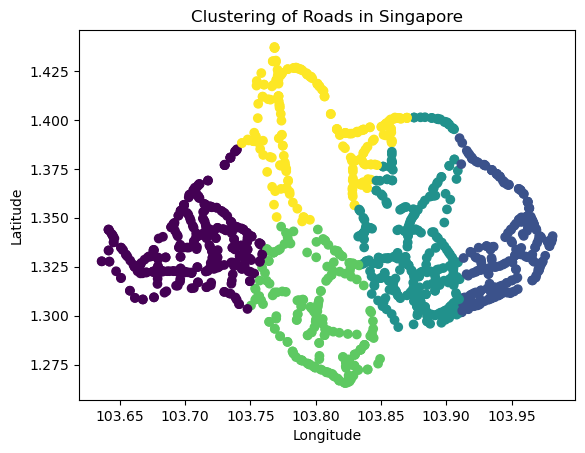

In [7]:
# longitude and latitude range of SG
latitude = [103.38, 104,6]
longitude = [1.09, 1.29]

# initial centers
initial_centers = [
    [1.35735, 103.7],   # 0: west
    [1.35735, 103.94],  # 1: east
    [1.35735, 103.82],  # 2: central
    [1.29587, 103.82],  # 3: south
    [1.41803, 103.82]   # 4: north
]

# Clustering using Kmeans
kmeans = KMeans(n_clusters=5, init=initial_centers, n_init=1)
road_df['Region'] = kmeans.fit_predict(road_df[['Longitude', 'Latitude']])

# Visualization
plt.scatter(road_df['Longitude'], road_df['Latitude'], c=road_df['Region'], cmap='viridis')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Clustering of Roads in Singapore')
plt.show()

In [8]:
road_df

,Longitude,Latitude,LinkID,Region
0,103.756717,1.309955,116000470,3
1,103.919245,1.310830,103055846,1
2,103.968792,1.344411,115000580,1
3,103.919946,1.380201,103064935,1
4,103.773292,1.403038,103066715,4
...,...,...,...,...
1307,103.735638,1.347417,103105910,0
1308,103.962323,1.358215,103061686,1
1309,103.743487,1.388148,103065790,4
1310,103.799687,1.273547,107000775,3


### 3.2 Polutant
#### 3.2.1 2017-2023
In this part, we analyzed the major pollutant indicators in various regions of Singapore from 2017 to 2023, including PM2.5, PM10, nitrogen dioxide (NO2), and ozone (O3). The data was sourced from the Pollutant Standards Index (PSI) dataset provided by the National Environment Agency (NEA) of Singapore. The concentration of each pollutant is measured in micrograms per cubic meter (µg/m³). To gain deeper insights into the trends of pollutants in different regions, we conducted the following steps of exploratory data analysis. 

<font size=4>**Correlation Heatmap of Pollutants** </font>  
By calculating the correlation coefficients between the pollutants, we generated a correlation heatmap (as shown above). This chart displays the degree of linear relationships between different pollutants, with correlation values ranging from -1 to 1, where values close to 1 indicate a strong positive correlation and values close to -1 indicate a strong negative correlation.
As seen from the chart, most pollutants show strong correlations with each other, suggesting they may share common sources, such as traffic congestion or industrial activities. Notably, ozone shows a lower correlation with other pollutants, which may indicate that its formation mechanism is different, for example, being influenced by sunlight intensity and weather conditions.  

<font size=4>**Trends in the Annual Average Values of Pollutants by Region**  </font>  
To analyze the changes in pollutant levels across different regions over the years, we used line charts to display the trends in the annual average values of pollutants from 2017 to 2023. The following chart shows the changes in Ozone (O3), Nitrogen Dioxide (NO2), PM2.5, and PM10 levels in Singapore's five main regions: East, West, North, South, and Central.
Key observations include：

**1.O3 Levels:**        Overall, ozone levels show a downward trend, especially after 2019. This could be related to Singapore's recent policy measures aimed at improving air quality.  
**2.NO2 and PM Levels:**    During the COVID-19 pandemic (2020), pollution levels experienced a temporary decline due to lockdowns and reduced vehicle usage, but levels started to rise again after 2022.  
**3.Regional Differences:**     The eastern and northern regions have generally higher pollutant concentrations, while the central and southern regions show relatively lower pollution levels. This could be attributed to traffic density and the distribution of industrial activities in these areas.  

<font size=4> **Annual Variation of Specific Pollutants** </font>  
The annual average values of each pollutant provide an effective tool for identifying trends. For instance, the concentrations of PM10 and PM2.5 showed significant declines in 2020, but gradually increased after 2022. This trend may be associated with the resumption of economic activities. Additionally, Ozone (O3) levels have steadily declined since 2017, especially in the western and central regions, possibly due to reductions in traffic emissions and stricter environmental regulations

In [9]:
#with open('data/1/pollutant.json', 'r') as file:
with open('data/pollutant.json', 'r') as file:
    pollutant = json.load(file)['data']['items'][0]['readings']
pollutant_df = pd.DataFrame(pollutant).T
# Concentration is measured in micrograms per cubic metre 
pollutant_df.sort_index()

pollutant_df_index = pollutant_df[pollutant_df.index.str.endswith('index')]
pollutant_df_index

,west,east,central,south,north
o3_sub_index,2,4,4,2,2
pm10_sub_index,19,17,21,15,16
so2_sub_index,5,3,2,2,1
pm25_sub_index,48,42,42,34,34
co_sub_index,6,5,6,3,4


/opt/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


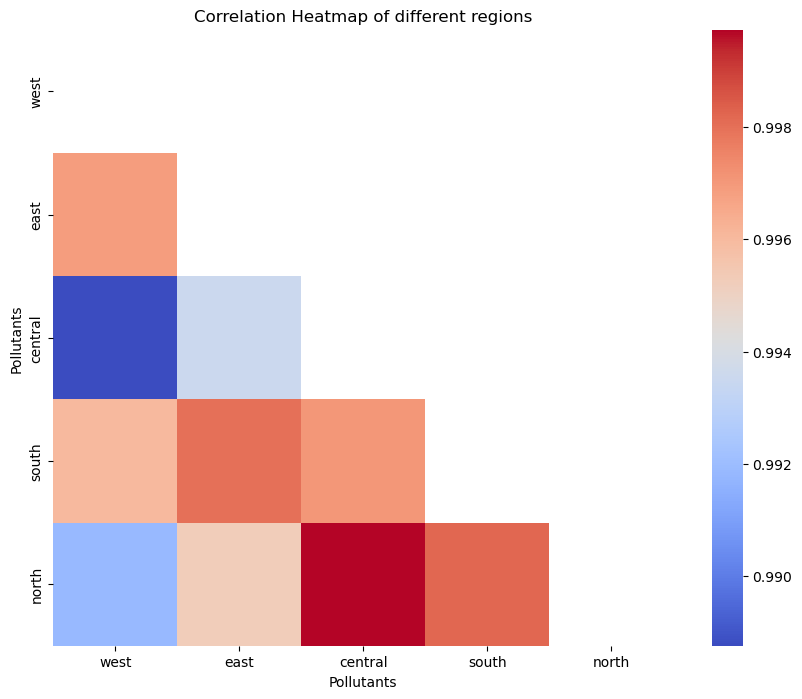

In [10]:
# get the concentration of pollutants of each region
corr_matrix = pollutant_df_index.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt='.2f')


plt.title('Correlation Heatmap of different regions')
plt.xlabel('Pollutants')
plt.ylabel('Pollutants')

plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


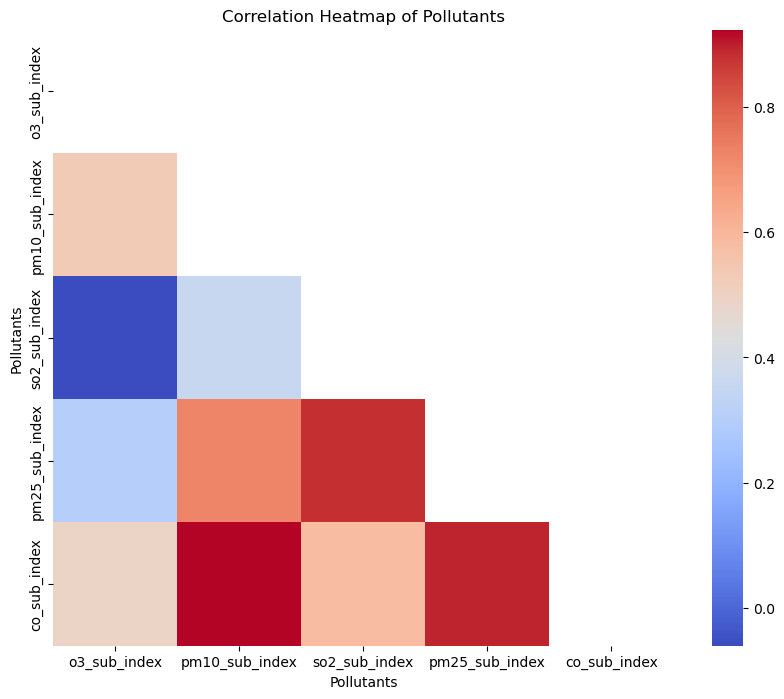

In [11]:
mask = np.triu(np.ones_like(pollutant_df_index.T.corr(), dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(pollutant_df_index.T.corr(), mask=mask, annot=True, cmap='coolwarm', fmt='.2f')


plt.title('Correlation Heatmap of Pollutants')
plt.xlabel('Pollutants')
plt.ylabel('Pollutants')

plt.show()

****

In [12]:
pollutant_df = pd.read_csv("data/pollutant_2017-2023.csv")
pollutant_df['date'] = pd.to_datetime(pollutant_df['date'])
pollutant_df['year'] = pollutant_df['date'].dt.year

# Define a function to safely evaluate and handle missing or incorrect data
def safe_eval(x):
    if pd.isna(x):
        return {}
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return {}
# Apply the safe_eval function to specific columns to safely process their values
columns_to_convert = ['o3_sub_index', 'no2_one_hour_max', 'o3_eight_hour_max', 
                       'psi_twenty_four_hourly', 'pm10_twenty_four_hourly', 'pm10_sub_index',
                       'pm25_twenty_four_hourly', 'pm25_sub_index', 'psi_three_hourly', 'so2_sub_index',
                       'so2_twenty_four_hourly', 'co_eight_hour_max','co_sub_index']
pollutant_df[columns_to_convert] = pollutant_df[columns_to_convert].applymap(safe_eval)
pollutant_df = pollutant_df.drop(columns=['index'])
pollutant_df


/var/folders/l7/d0lb4fb15qx7kr983gqvzs2c0000gn/T/ipykernel_3506/271704666.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pollutant_df[columns_to_convert] = pollutant_df[columns_to_convert].applymap(safe_eval)


,o3_sub_index,no2_one_hour_max,o3_eight_hour_max,psi_twenty_four_hourly,pm10_twenty_four_hourly,pm10_sub_index,pm25_twenty_four_hourly,pm25_sub_index,psi_three_hourly,so2_sub_index,so2_twenty_four_hourly,co_eight_hour_max,co_sub_index,date,year
0,"{'west': 13, 'national': 14, 'east': 14, 'cent...","{'west': 4, 'national': 24, 'east': 17, 'centr...","{'west': 30, 'national': 32, 'east': 32, 'cent...","{'west': 33, 'national': 43, 'east': 43, 'cent...","{'west': 17, 'national': 23, 'east': 21, 'cent...","{'west': 17, 'national': 23, 'east': 21, 'cent...","{'west': 8, 'national': 10, 'east': 10, 'centr...","{'west': 33, 'national': 43, 'east': 43, 'cent...","{'west': 25, 'national': 42, 'east': 52, 'cent...","{'west': 2, 'national': 2, 'east': 2, 'central...","{'west': 3, 'national': 4, 'east': 4, 'central...","{'west': 0.28, 'national': 0.71, 'east': 0.2, ...","{'west': 3, 'national': 7, 'east': 2, 'central...",2017-01-01,2017
1,"{'west': 7, 'national': 7, 'east': 6, 'central...","{'west': 21, 'national': 31, 'east': 22, 'cent...","{'west': 17, 'national': 17, 'east': 15, 'cent...","{'west': 29, 'national': 51, 'east': 51, 'cent...","{'west': 18, 'national': 25, 'east': 23, 'cent...","{'west': 18, 'national': 25, 'east': 23, 'cent...","{'west': 7, 'national': 12, 'east': 12, 'centr...","{'west': 29, 'national': 51, 'east': 51, 'cent...","{'west': 23, 'national': 35, 'east': 51, 'cent...","{'west': 2, 'national': 4, 'east': 3, 'central...","{'west': 3, 'national': 7, 'east': 6, 'central...","{'west': 0.32, 'national': 0.85, 'east': 0.25,...","{'west': 3, 'national': 9, 'east': 2, 'central...",2017-01-02,2017
2,"{'west': 16, 'national': 16, 'east': 11, 'cent...","{'west': 12, 'national': 25, 'east': 8, 'centr...","{'west': 38, 'national': 38, 'east': 26, 'cent...","{'west': 28, 'national': 50, 'east': 45, 'cent...","{'west': 15, 'national': 21, 'east': 21, 'cent...","{'west': 15, 'national': 21, 'east': 21, 'cent...","{'west': 7, 'national': 12, 'east': 11, 'centr...","{'west': 28, 'national': 50, 'east': 45, 'cent...","{'west': 18, 'national': 28, 'east': 27, 'cent...","{'west': 2, 'national': 3, 'east': 3, 'central...","{'west': 3, 'national': 4, 'east': 4, 'central...","{'west': 0.3, 'national': 0.54, 'east': 0.17, ...","{'west': 3, 'national': 5, 'east': 2, 'central...",2017-01-03,2017
3,"{'west': 24, 'national': 24, 'east': 14, 'cent...","{'west': 21, 'national': 27, 'east': 9, 'centr...","{'west': 57, 'national': 57, 'east': 32, 'cent...","{'west': 24, 'national': 35, 'east': 35, 'cent...","{'west': 12, 'national': 16, 'east': 16, 'cent...","{'west': 12, 'national': 16, 'east': 16, 'cent...","{'west': 5, 'national': 8, 'east': 8, 'central...","{'west': 23, 'national': 35, 'east': 35, 'cent...","{'west': 21, 'national': 35, 'east': 27, 'cent...","{'west': 2, 'national': 3, 'east': 3, 'central...","{'west': 2, 'national': 5, 'east': 5, 'central...","{'west': 0.32, 'national': 0.56, 'east': 0.19,...","{'west': 3, 'national': 6, 'east': 2, 'central...",2017-01-04,2017
4,"{'west': 13, 'national': 15, 'east': 15, 'cent...","{'west': 11, 'national': 40, 'east': 14, 'cent...","{'west': 30, 'national': 35, 'east': 35, 'cent...","{'west': 24, 'national': 42, 'east': 36, 'cent...","{'west': 14, 'national': 20, 'east': 18, 'cent...","{'west': 14, 'national': 20, 'east': 18, 'cent...","{'west': 6, 'national': 10, 'east': 9, 'centra...","{'west': 24, 'national': 42, 'east': 36, 'cent...","{'west': 14, 'national': 28, 'east': 28, 'cent...","{'west': 2, 'national': 3, 'east': 2, 'central...","{'west': 3, 'national': 5, 'east': 4, 'central...","{'west': 0.22, 'national': 0.65, 'east': 0.24,...","{'west': 2, 'national': 6, 'east': 2, 'central...",2017-01-05,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2551,"{'west': 5, 'east': 11, 'central': 6, 'south':...","{'west': 17, 'east': 19, 'central': 45, 'south...","{'west': 11, 'east': 26, 'central': 13, 'south...","{'west': 21, 'east': 44, 'central': 30, 'south...","{'west'

In [13]:
num_empty_dicts = pollutant_df['psi_three_hourly'].apply(lambda x: x == {}).sum()
print(num_empty_dicts)
print(pollutant_df['psi_three_hourly'].count())
''' 
    psi_three_hourly contains too much empty value (2483/2556) -> drop
'''
pollutant_df = pollutant_df.drop(columns=['psi_three_hourly'])

2483
2556


In [14]:
o3_index = pollutant_df['o3_sub_index'].apply(pd.Series)
o3_index_df = pd.concat([pollutant_df['year'], o3_index], axis=1)
o3_index_df

,year,west,national,east,central,south,north
0,2017,13.0,14.0,14.0,8.0,7.0,12.0
1,2017,7.0,7.0,6.0,6.0,4.0,6.0
2,2017,16.0,16.0,11.0,6.0,6.0,9.0
3,2017,24.0,24.0,14.0,12.0,14.0,12.0
4,2017,13.0,15.0,15.0,9.0,9.0,10.0
...,...,...,...,...,...,...,...
2551,2023,5.0,NaN,11.0,6.0,3.0,8.0
2552,2023,4.0,NaN,13.0,5.0,3.0,8.0
2553,2023,10.0,NaN,17.0,7.0,6.0,12.0
2554,2023,2.0,NaN,9.0,7.0,3.0,3.0


In [15]:
average_df = o3_index_df.groupby('year').mean().reset_index()
average_df

,year,west,national,east,central,south,north
0,2017,17.204986,19.628809,13.434903,13.490305,11.002770,15.376731
1,2018,14.723288,17.684932,11.254795,13.646575,12.345205,14.191781
2,2019,9.175000,14.628571,10.196429,13.571429,10.578571,11.285714
3,2020,9.110497,14.966851,10.621547,13.273481,11.850829,12.488950
4,2021,10.529412,16.414566,11.473389,14.509804,11.761905,14.095238
5,2022,9.513736,16.222527,12.719780,13.673077,7.873626,13.576923
6,2023,8.488532,16.715789,10.838525,14.308508,9.025251,14.981204


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


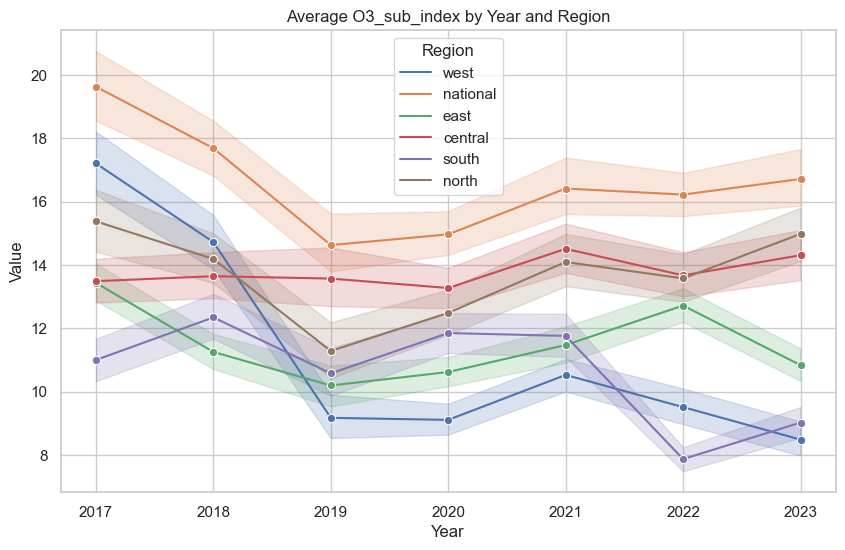

In [16]:
melted_df = o3_index_df.melt(id_vars='year', var_name='region', value_name='value')
# melted_df = o3_indexa_df.melt(id_vars='year', var_name='region', value_name='value')

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.lineplot(data=melted_df, x='year', y='value', hue='region', marker='o')

plt.title('Average O3_sub_index by Year and Region')
plt.xlabel('Year')
plt.ylabel('Value')

plt.legend(title='Region')

plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

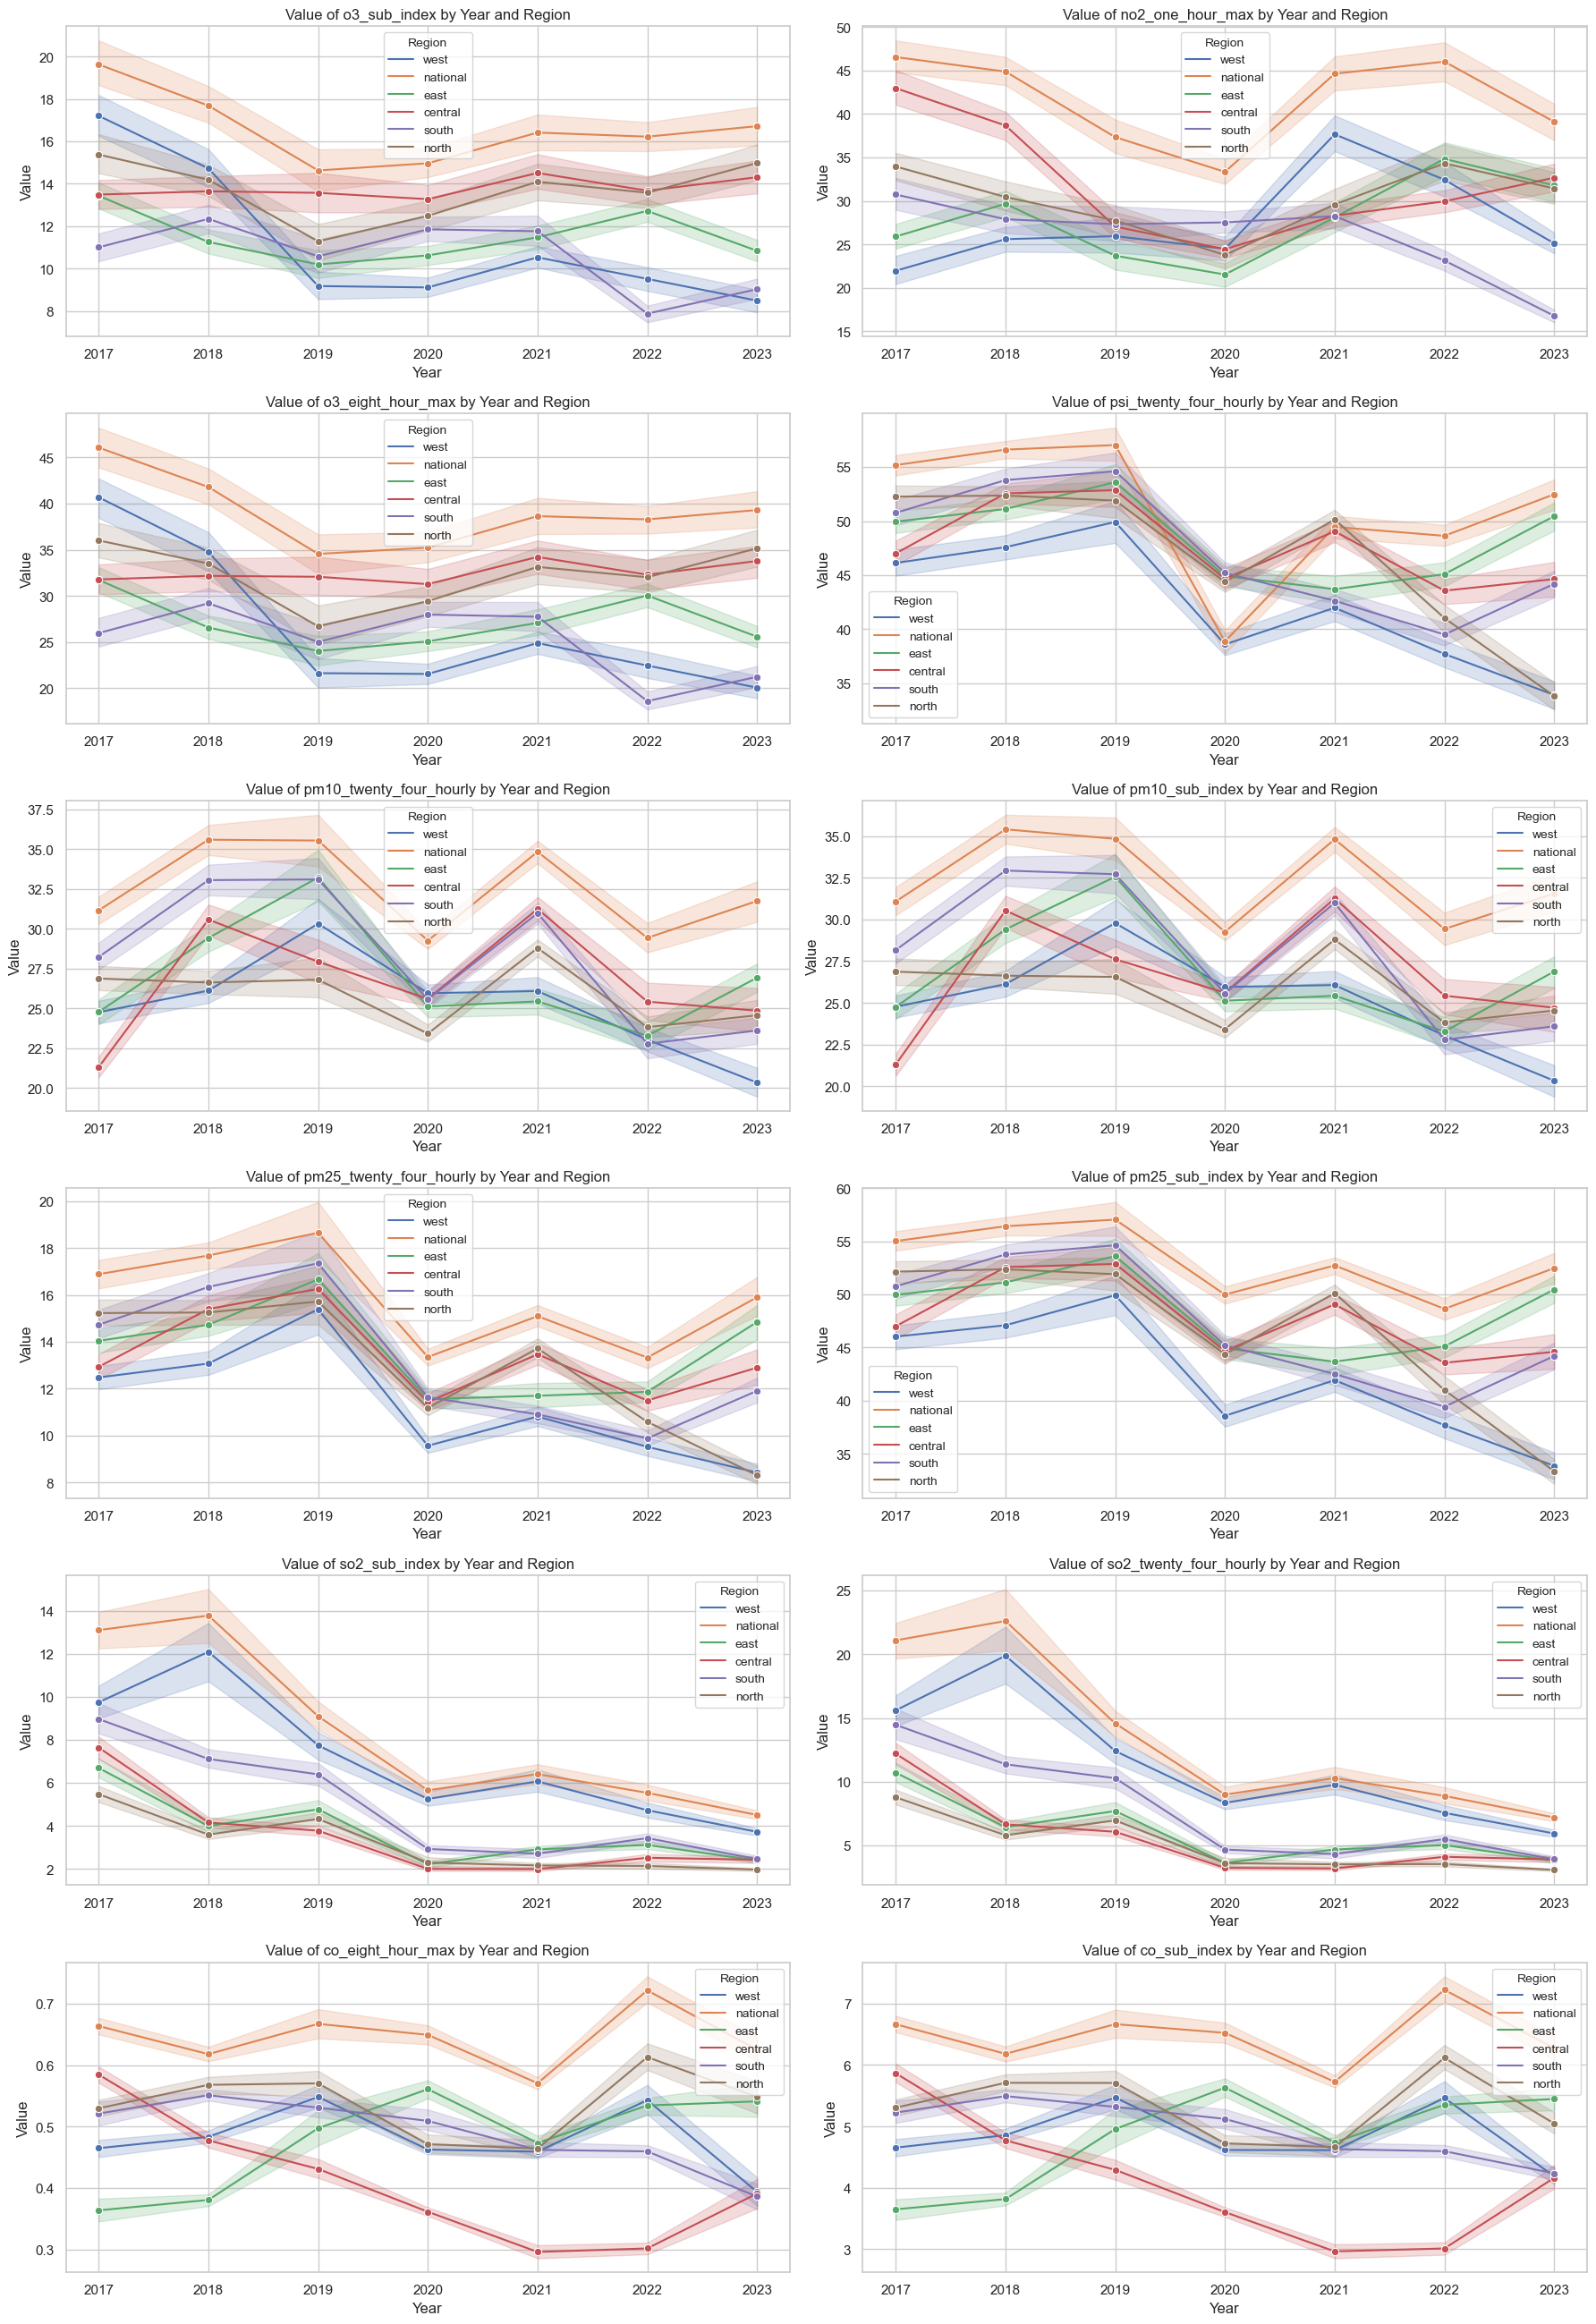

In [17]:
pos = 1
columns_to_convert.remove('psi_three_hourly')

plt.figure(figsize=(18, 30))

for column in columns_to_convert:
    column_df = pollutant_df[column].apply(pd.Series)   
    column_df = pd.concat([pollutant_df['year'], column_df], axis=1)
    # average_df = column_df.groupby('year').mean().reset_index()
    plt.subplot(7, 2, pos)

    melted_df = column_df.melt(id_vars='year', var_name='region', value_name='value')
    sns.set(style="whitegrid")
   
    sns.lineplot(data=melted_df, x='year', y='value', hue='region', marker='o')

    plt.title('Value of {} by Year and Region'.format(column))
    plt.legend(title='Region', fontsize='small', title_fontsize='small')
    plt.xlabel('Year')
    plt.ylabel('Value')
    pos = pos + 1

plt.tight_layout()
plt.show()
    

#### 3.2.2 2024-02

To further analyze the air quality in different regions of Singapore, we conducted an in-depth analysis of pollutant data for February 2024. The dataset provided by the National Environment Agency (NEA) includes key pollutant indicators such as PM2.5, PM10, nitrogen dioxide (NO2), ozone (O3), sulfur dioxide (SO2), and carbon monoxide (CO). The concentration of each pollutant is measured in micrograms per cubic meter (µg/m³) or other relevant units.

By plotting the concentration values of each pollutant across different regions (East, West, North, South, Central) on a daily line chart, we can identify trends and regional differences in pollutant levels throughout February.

**1. Ozone (O3) Index**  
O3 Sub-Index and O3 8-Hour Max: The data shows that the concentration of ozone in the West and North experienced some fluctuations at the beginning and middle of the month, but overall the trend remained stable. In contrast, ozone concentrations in the South and East stayed at relatively low levels.  
Trend Summary: While there were some daily fluctuations in O3 levels, there were no extreme peaks, indicating relatively stable weather conditions and pollutant sources during February. 

**2. Nitrogen Dioxide (NO2)**    
NO2 1-Hour Max: The NO2 concentration in the East and Central regions saw noticeable increases at the beginning and end of the month, especially in industrial areas and regions with heavy traffic. In contrast, NO2 levels in the West and South remained low.  
Trend Summary: NO2 peaked mainly at the beginning and end of the month, possibly corresponding to traffic peaks or industrial activity.  

**3. Particulate Matter (PM10 and PM2.5)**    
PM10 and PM2.5: The data reveals that particulate matter levels in the West and North peaked in mid-February, which may be related to construction activities or industrial emissions. PM2.5 concentrations fluctuated significantly, with lower volatility in the East and Central regions compared to other regions.  
Trend Summary: Particulate matter concentrations showed significant fluctuations throughout February, potentially influenced by local weather conditions or industrial activities. 

**4. Sulfur Dioxide (SO2)**    
SO2 Sub-Index and SO2 24-Hour Average: SO2 concentrations in the South and West remained low, indicating relatively good air quality in these areas. However, the North saw a spike in SO2 levels in mid-February, possibly due to industrial emissions.  
Trend Summary: SO2 concentrations were generally low but showed short-term fluctuations in certain regions, indicating temporary changes in air quality.  

**5. Carbon Monoxide (CO)**    
CO 8-Hour Max: CO concentrations fluctuated significantly, with noticeable increases in the North and West in mid-February, likely due to vehicle emissions in areas with heavy traffic.  
Trend Summary: CO concentrations exhibited clear regional differences, particularly in the North where CO levels fluctuated more dramatically.  

In [18]:
pollutant_feb_df = pd.read_csv("data/pollutant_202402.csv")
pollutant_feb_df['date'] = pd.to_datetime(pollutant_feb_df['date'])
pollutant_feb_df['day'] = pollutant_feb_df['date'].dt.day
# define a function to safely evaluate and handle missing or incorrect data
def safe_eval(x):
    if pd.isna(x):
        return {}
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return {}
    
columns_to_convert = ['o3_sub_index', 'no2_one_hour_max', 'o3_eight_hour_max', 
                       'psi_twenty_four_hourly', 'pm10_twenty_four_hourly', 'pm10_sub_index',
                       'pm25_twenty_four_hourly', 'pm25_sub_index', 'so2_sub_index',
                       'so2_twenty_four_hourly', 'co_eight_hour_max','co_sub_index']
pollutant_feb_df[columns_to_convert] = pollutant_feb_df[columns_to_convert].applymap(safe_eval)
pollutant_feb_df = pollutant_feb_df.drop(columns=['index'])

/var/folders/l7/d0lb4fb15qx7kr983gqvzs2c0000gn/T/ipykernel_3506/2988386799.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pollutant_feb_df[columns_to_convert] = pollutant_feb_df[columns_to_convert].applymap(safe_eval)


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

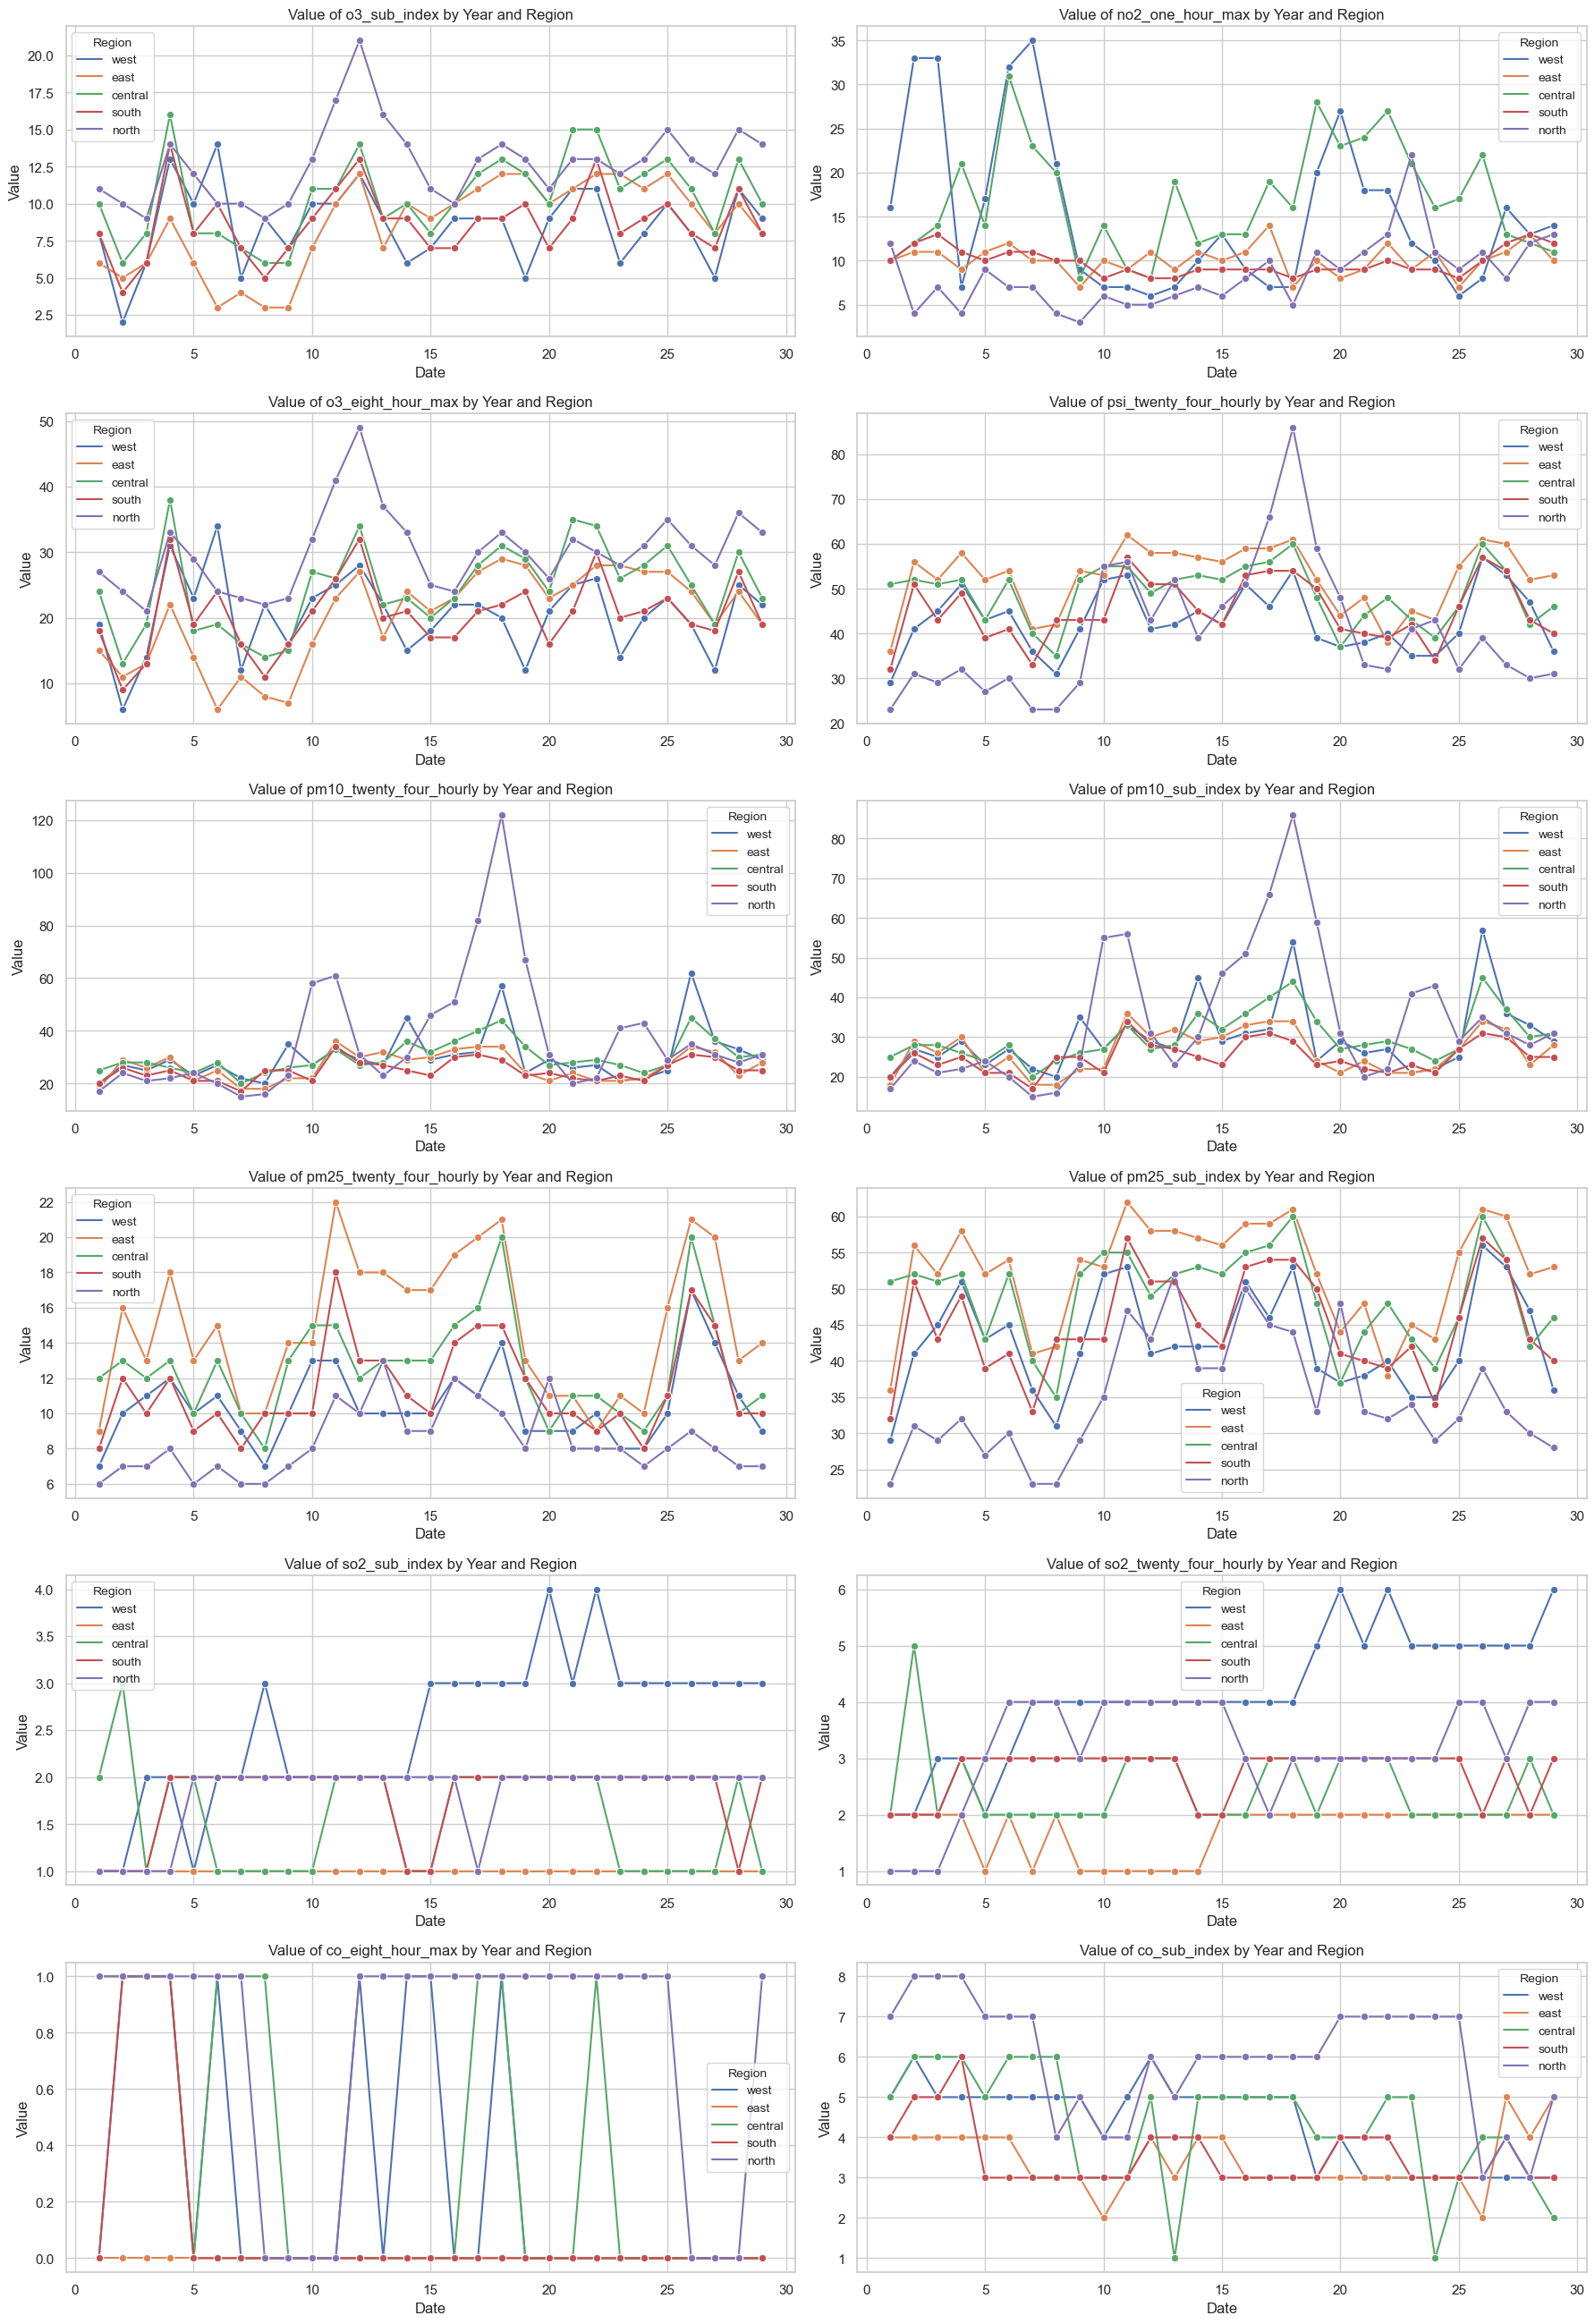

In [19]:
pos = 1
# columns_to_convert.remove('psi_three_hourly')

plt.figure(figsize=(18, 30))

for column in columns_to_convert:
    column_df = pollutant_feb_df[column].apply(pd.Series)   
    column_df = pd.concat([pollutant_feb_df['day'], column_df], axis=1)
    # average_df = column_df.groupby('year').mean().reset_index()
    plt.subplot(7, 2, pos)

    melted_df = column_df.melt(id_vars='day', var_name='region', value_name='value')
    sns.set(style="whitegrid")

    sns.lineplot(data=melted_df, x='day', y='value', hue='region', marker='o')

    plt.title('Value of {} by Year and Region'.format(column))
    plt.legend(title='Region', fontsize='small', title_fontsize='small')
    plt.xlabel('Date')
    plt.ylabel('Value')
    pos = pos + 1

plt.tight_layout()
plt.show()
    

### 3.3 MVP01-1_MVP_by_type

We analyzed the total number of motor vehicles and the changes in different vehicle categories in Singapore from 2005 to 2023. The data comes from the annual statistics on motor vehicle population (MVP) by type.

***1. Trend in Total Vehicle Population***    
From 2005 to 2023, the total number of motor vehicles showed a general upward trend. In 2005, the total vehicle population was around 800,000, gradually increasing until it peaked at nearly 1 million in 2014. Since then, the total number has stabilized, maintaining around 1 million.  
This trend indicates that as Singapore's population and economy grew, so did the number of motor vehicles. However, in recent years, government policies such as the Certificate of Entitlement (COE) scheme may have effectively curbed excessive vehicle growth.

***2. Changes in Different Vehicle Categories***    
**(1) Cars and Station-wagons:** The number of vehicles in this category steadily increased from 2005, peaking around 2013, and has since remained between 600,000 to 650,000. This category accounts for the largest proportion of the total motor vehicle population, reflecting the dominance of private cars in Singapore's transportation system.  
**(2) Motorcycles and Scooters:** The number of motorcycles has remained relatively stable throughout the period, at around 140,000. This shows that while motorcycles are not as widespread as cars, they still play a significant role in Singapore's transportation.  
**(3) Buses:** The number of buses has changed little, remaining at around 10,000, indicating stable public transportation infrastructure in terms of vehicle supply.  
**(4) Taxis:** The number of taxis remained stable at around 20,000 between 2005 and 2017 but saw a significant decline after 2017, likely due to the rise of ride-hailing services.  
**(5) Goods and Other Vehicles:** This category shows a slow but steady increase, reflecting growing demand for logistics and freight services as the economy develops.  
**(6) Tax Exempted Vehicles:** The number has remained low, below 5,000, indicating little change in this special category of vehicles.

***3. Comparison Between Categories***   
The charts show that cars and station-wagons far outnumber other vehicle categories, reflecting the prevalence of private vehicles.
The sharp decline in the number of taxis after 2017 suggests that the rise of ride-hailing services has significantly impacted the traditional taxi industry. Meanwhile, public transport vehicles like buses and motorcycles have maintained relatively stable numbers. The steady growth in the number of goods and other vehicles corresponds to increased demand in the logistics sector, driven by economic activity.

    year  number
0   2005  754992
1   2006  799373
2   2007  851336
3   2008  893803
4   2009  925518
5   2010  945829
6   2011  956704
7   2012  969910
8   2013  974170
9   2014  972037
10  2015  957246
11  2016  956430
12  2017  961842
13  2018  957006
14  2019  973101
15  2020  973990
16  2021  988755
17  2022  995746
18  2023  996732


<Axes: xlabel='year'>

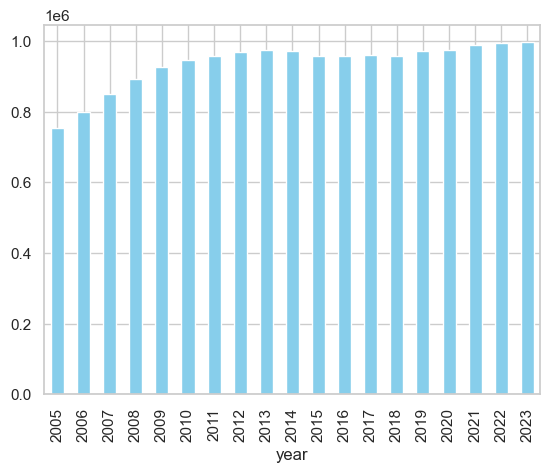

In [20]:
# get the total number of vehicles by year
MPY_type = pd.read_csv("data/MVP01-1_MVP_by_type.csv")
vehicle_population_df = MPY_type.groupby(['year'])['number'].sum().reset_index()
print(vehicle_population_df)
vehicle_population_df.plot(kind='bar', x='year', y='number', color='skyblue', legend=False)


In [21]:
# get the number of vehicles by type
temp = MPY_type[MPY_type['category'] == 'Cars and Station-wagons']
temp = temp.rename(columns={'number': 'Cars and Station-wagons number'})
vehicle_population_df = temp.assign(C=temp['Cars and Station-wagons number'])
vehicle_population_df

,year,category,type,Cars and Station-wagons number,C
0,2005,Cars and Station-wagons,Private cars,401638,401638
1,2006,Cars and Station-wagons,Private cars,421904,421904
2,2007,Cars and Station-wagons,Private cars,451745,451745
3,2008,Cars and Station-wagons,Private cars,476634,476634
4,2009,Cars and Station-wagons,Private cars,497116,497116
...,...,...,...,...,...
371,2023,Cars and Station-wagons,Company cars,35429,35429
372,2023,Cars and Station-wagons,Tuition cars,770,770
373,2023,Cars and Station-wagons,Private Hire (Self-Drive) cars,28306,28306
374,2023,Cars and Station-wagons,Private Hire (Chauffeur) cars,53448,53448


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


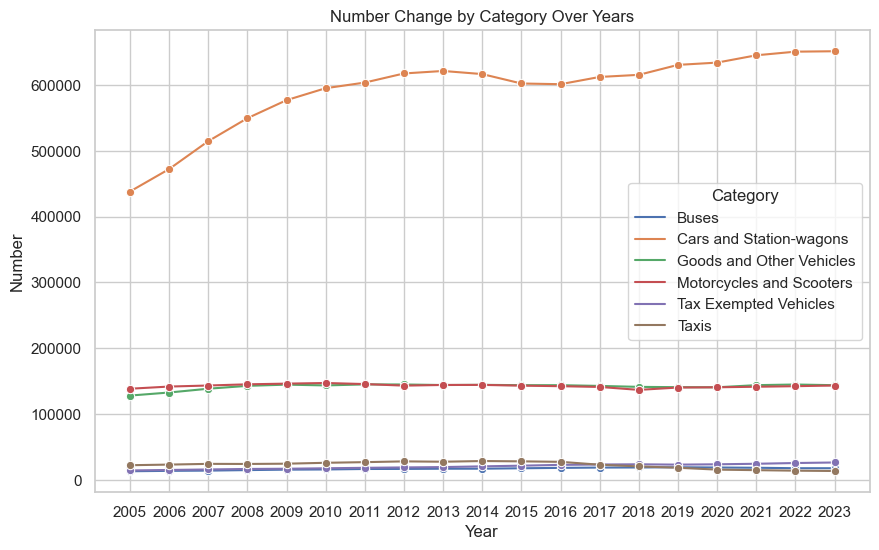

In [22]:
MPY_type = pd.read_csv("data/MVP01-1_MVP_by_type.csv")
categoty_df = MPY_type.groupby(['category','year'])['number'].sum().reset_index()

sns.set(style="whitegrid")

# Visualization
plt.figure(figsize=(10, 6))
sns.lineplot(data=categoty_df, x='year', y='number', hue='category', marker='o')

plt.title('Number Change by Category Over Years')
plt.xlabel('Year')
plt.ylabel('Number')
plt.legend(title='Category')
plt.xticks(categoty_df['year'].unique())  
plt.grid(True)


**Focus on the "Cars and Station-wagons" category**

We further focused on the "Cars and Station-wagons" category, analyzing the changes in the number of different types of cars and station wagons from 2005 to 2023. This category is subdivided into types such as Company Cars, Off-Peak Cars, Rental Cars, Private Cars, Private Hire (Chauffeur), Private Hire (Self-Drive), and Tuition Cars.  
**1. Company Cars**  
The number of company cars saw significant growth between 2005 and 2013, after which it stabilized at a high level, maintaining around 500,000 vehicles in recent years. This trend indicates that company cars form an important part of the vehicle fleet in Singapore, and their numbers remain steady, possibly due to fixed corporate demand for vehicles.  
**2. Private Cars**  
The number of private cars showed a relatively steady growth trend throughout the period. As Singapore's economy developed and household incomes increased, more families acquired private cars. However, due to the government's strict control on the number of private cars, the growth trend did not show a sharp spike.  
**3. Private Hire Vehicles (Chauffeur and Self-Drive)**  
Both chauffeur-driven and self-drive private hire vehicles increased after 2018, especially as the growth in private cars slowed, making rental vehicles an alternative choice for many. This phenomenon may be related to the rise of ride-hailing services, as more residents opt for rentals or shared mobility to meet their travel needs.  
**4. Rental and Other Categories**  
Other types of vehicles, such as tuition cars and rental cars, remained relatively few in number but have seen some growth over the past few years, indicating increasing demand for these services as the service sector develops.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


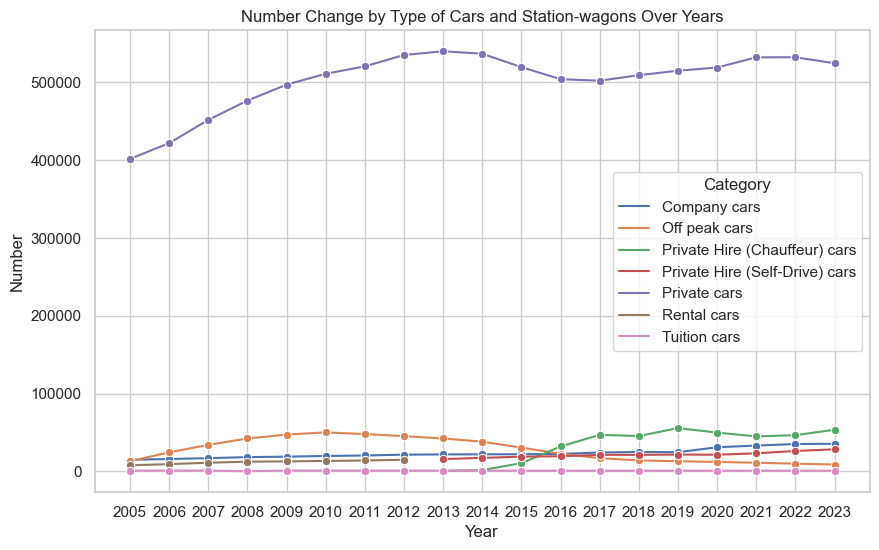

In [23]:
car_df = MPY_type[MPY_type['category'] == 'Cars and Station-wagons'].groupby(['type','year'])['number'].sum().reset_index()

sns.set(style="whitegrid")

# Visualization
plt.figure(figsize=(10, 6))
sns.lineplot(data=car_df, x='year', y='number', hue='type', marker='o')

plt.title('Number Change by Type of Cars and Station-wagons Over Years')
plt.xlabel('Year')
plt.ylabel('Number')
plt.legend(title='Category')
plt.xticks(car_df['year'].unique())  
plt.grid(True)

### 3.4 New_Reg_by_COE

The Certificate of Entitlement (COE) system in Singapore categorizes vehicles into various types, which determine the registration and bidding process for new vehicles. The categories are as follows:  
**Category A:** Cars with engine capacity up to 1,600cc and maximum power output up to 97kW (130bhp).  
**Category B:** Cars with engine capacity above 1,600cc or maximum power output above 97kW (130bhp).  
**Category C:** Goods Vehicles & Buses.  
**ategory C-ETS:** Refers to the Early Turnover Scheme (ETS). From April 1, 2021, to March 31, 2025, vehicle owners can deregister their existing Euro 2/3/4 Category C diesel vehicles and register eligible replacement vehicles within one month of deregistration by paying a discounted Prevailing Quota Premium (PQP) under the enhanced ETS.  
**Category D:** Motorcycles.  
**Taxis:** Before August 2012, taxi operators could bid for a new COE or pay the PQP to register a new taxi under Category A. From August 6, 2012, onwards, all taxis pay for COEs based on the PQP of Category A.  
**Vehicles Exempted from VQS:** These include scheduled and school buses, emergency vehicles, engineering plants primarily for off-road use, diplomatic vehicles, and vehicles under the Disabled Person Scheme.  

***Key Observations from the Chart***  
**Category A and Category B:** There was a sharp decline in the number of vehicles registered under these categories after 2010, with a peak occurring around that period. The number of newly registered vehicles under both categories has remained relatively low since then.  
**Category C (Goods Vehicles & Buses):** The number of new registrations under this category has been relatively stable over the years, with minor fluctuations.  
**Category C-ETS:** This category saw a noticeable increase in recent years, likely due to the enhanced Early Turnover Scheme encouraging the replacement of older vehicles.  
**Category D (Motorcycles):** The number of motorcycles registered has shown some fluctuation but generally remained consistent over the period.  
**Taxis:** The number of new taxis registered declined sharply after 2012, likely due to changes in regulation and the rise of ride-hailing services.  
**Vehicles Exempted from VQS:** The number of these vehicles remained consistently low throughout the period.

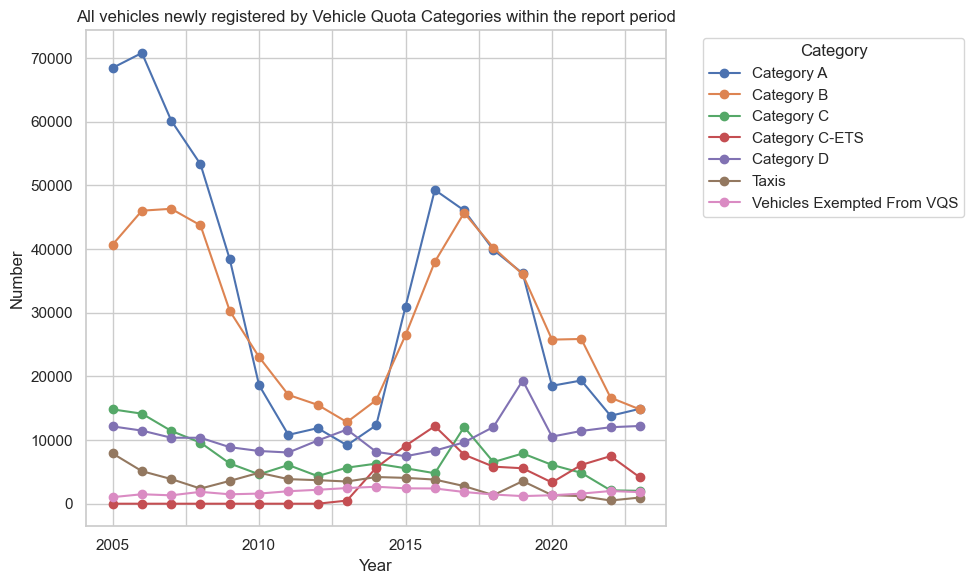

In [24]:

COE_df = pd.read_csv('data/MVP02-1_New_Reg_by_COE.csv')
COE_df['year'] = COE_df['year'].astype(str)
# Visualization
pivot_table = COE_df.pivot_table(index='year', columns='category', values='number', aggfunc='sum')

pivot_table.plot(marker='o', figsize=(10, 6))
plt.title('All vehicles newly registered by Vehicle Quota Categories within the report period')
plt.xlabel('Year')
plt.ylabel('Number')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

### 3.5 MVP02-2_New_Cars_by_make_type

This analysis explores the number of newly registered cars in Singapore based on the fuel type used from 2015 to 2023. The different fuel categories include Diesel, Diesel-Electric, Electric, Petrol, Petrol-Electric, and their respective plug-in variants, among others.

***Petrol Vehicles:***
1. Petrol vehicles have consistently accounted for the largest portion of newly registered vehicles. The number of petrol vehicles peaked in 2016, with over 80,000 registrations, followed by a steady decline in the subsequent years, reaching below 10,000 by 2023.
The significant decrease in petrol vehicle registrations may be attributed to policies aimed at reducing carbon emissions and the increasing shift toward electric or hybrid vehicles.
Diesel and Diesel-Electric Vehicles:

2. Diesel and Diesel-Electric vehicles have experienced relatively low and stable registration numbers, with little growth observed over the period.
This could be due to government incentives promoting cleaner alternatives, discouraging the use of traditional diesel vehicles due to their higher emissions.
Electric Vehicles:

3. The number of electric vehicles remained minimal between 2015 and 2020 but saw a noticeable increase after 2021, reflecting a growing interest in electric vehicles as they become more accessible and affordable.
This rise also aligns with global trends toward electric vehicles as part of efforts to combat climate change.

***Hybrid Vehicles (Petrol-Electric and Diesel-Electric):***  
Hybrid vehicles, both petrol-electric and diesel-electric, have shown gradual growth over the years. Notably, petrol-electric plug-in hybrids saw an increase in registrations starting in 2022, indicating growing consumer adoption of hybrid technology as a compromise between traditional fuel and electric vehicles.

***Other Vehicles:***  
The category "Others" shows a relatively small number of registrations, which could include alternative fuel vehicles or less common types of cars.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


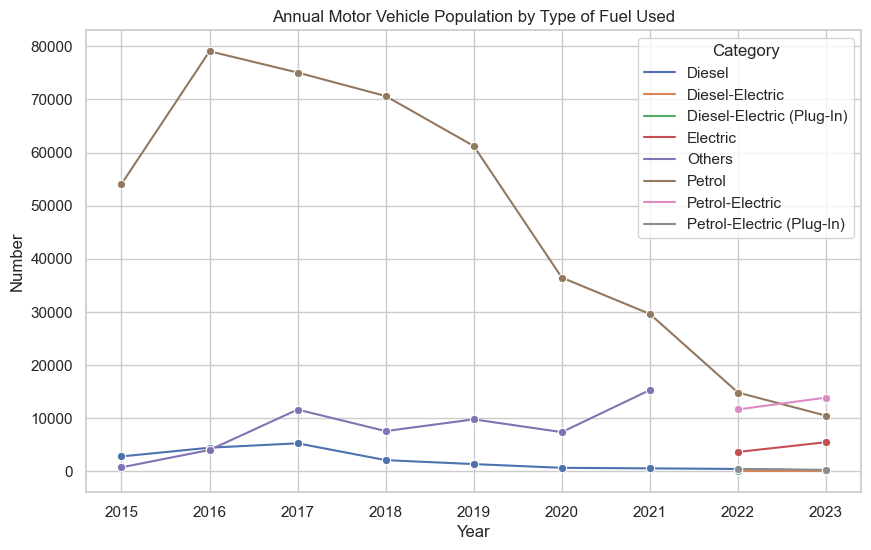

In [25]:
make_type_df = pd.read_csv('data/MVP02-2_New_Cars_by_make_type.csv')
# group by fuel and year
make_type_group_df = make_type_df.groupby(['fuel', 'year'])['number'].sum().reset_index()


sns.set(style="whitegrid")

# Visualization
plt.figure(figsize=(10, 6))
sns.lineplot(data=make_type_group_df, x='year', y='number', hue='fuel', marker='o')

plt.title('Annual Motor Vehicle Population by Type of Fuel Used')
plt.xlabel('Year')
plt.ylabel('Number')
plt.legend(title='Category')
plt.xticks(make_type_group_df['year'].unique())  
plt.grid(True)



### 3.6 Traffic Flow

Traffic Flow Analysis for 7 a.m. and 8 a.m. (February 2024)
In this analysis, we explored the traffic flow at two different times of day, 7 a.m. and 8 a.m., across five regions of Singapore: West, East, Central, South, and North. Traffic volume data was collected for each day in February 2024.  

***1. Traffic Flow at 7 a.m.***    
**General Trends:** Traffic flow shows distinct peaks on weekdays, with volumes dropping significantly over the weekends. The highest traffic volumes are observed in the West and Central regions, with volumes exceeding 500,000 vehicles per day during peak times.  

**Region-wise Observations**  
West: Consistently records the highest traffic flow across the month, with strong peaks on weekdays.  
Central: Also shows high traffic volumes, likely due to its role as the business hub of Singapore.  
North and South: These regions show lower traffic volumes compared to the West and Central areas but follow a similar trend of weekday peaks and weekend troughs.  

***2. Traffic Flow at 8 a.m.***  
**General Trends:** Similar to the 7 a.m. traffic flow, the 8 a.m. traffic also peaks on weekdays. The patterns across regions remain largely consistent with those observed at 7 a.m., although the traffic volumes increase slightly in the Central and East regions at 8 a.m. 
 
**Region-wise Observations**   
Central: Shows the most significant increase in traffic volume between 7 a.m. and 8 a.m., likely due to commuters heading to work.  
East: Experiences a noticeable rise in traffic volume at 8 a.m., indicating that this region sees increased commuting activity during this time.  
North and South: These regions exhibit less pronounced changes between 7 a.m. and 8 a.m., with traffic volumes remaining more stable.  

In [26]:
road_df

,Longitude,Latitude,LinkID,Region
0,103.756717,1.309955,116000470,3
1,103.919245,1.310830,103055846,1
2,103.968792,1.344411,115000580,1
3,103.919946,1.380201,103064935,1
4,103.773292,1.403038,103066715,4
...,...,...,...,...
1307,103.735638,1.347417,103105910,0
1308,103.962323,1.358215,103061686,1
1309,103.743487,1.388148,103065790,4
1310,103.799687,1.273547,107000775,3


In [27]:
with open('data/traffic_flow.json', 'r') as file:
    tf_flow = json.load(file)['Value']

tf_flow_df = pd.DataFrame(tf_flow)
tf_flow_df['HourOfDate'] = tf_flow_df['HourOfDate'].astype(int)
tf_flow_df['Volume'] = tf_flow_df['Volume'].astype(int)

# drop unnecessary columns
tf_flow_df = tf_flow_df.drop(columns=['StartLon', 'StartLat', 'EndLon', 'EndLat', 'RoadName', 'RoadCat'])
# get the traffic flow of 7am and 8am
tf_flow_7h_df = tf_flow_df[tf_flow_df['HourOfDate'] == 7]
tf_flow_8h_df = tf_flow_df[tf_flow_df['HourOfDate'] == 8]

tf_flow_7h_df

,LinkID,Date,HourOfDate,Volume
0,103000122,01/02/2024,7,3881
2,103000122,02/02/2024,7,4056
4,103000122,03/02/2024,7,2687
6,103000122,04/02/2024,7,1639
8,103000122,05/02/2024,7,3843
...,...,...,...,...
75491,118001452,25/02/2024,7,999
75493,118001452,26/02/2024,7,2178
75495,118001452,27/02/2024,7,2233
75497,118001452,28/02/2024,7,2171


In [28]:
merged_7h_df = pd.merge(tf_flow_7h_df, road_df, on=['LinkID'], how='left')
merged_7h_df['Date'] = pd.to_datetime(merged_7h_df['Date'], format="%d/%m/%Y")
merged_7h_df['Day'] = merged_7h_df['Date'].dt.day

merged_8h_df = pd.merge(tf_flow_8h_df, road_df, on=['LinkID'], how='left')
merged_8h_df['Date'] = pd.to_datetime(merged_8h_df['Date'], format="%d/%m/%Y")
merged_8h_df['Day'] = merged_8h_df['Date'].dt.day


merged_7h_df

,LinkID,Date,HourOfDate,Volume,Longitude,Latitude,Region,Day
0,103000122,2024-02-01,7,3881,103.694888,1.351109,0,1
1,103000122,2024-02-02,7,4056,103.694888,1.351109,0,2
2,103000122,2024-02-03,7,2687,103.694888,1.351109,0,3
3,103000122,2024-02-04,7,1639,103.694888,1.351109,0,4
4,103000122,2024-02-05,7,3843,103.694888,1.351109,0,5
...,...,...,...,...,...,...,...,...
37742,118001452,2024-02-25,7,999,103.703242,1.361749,0,25
37743,118001452,2024-02-26,7,2178,103.703242,1.361749,0,26
37744,118001452,2024-02-27,7,2233,103.703242,1.361749,0,27
37745,118001452,2024-02-28,7,2171,103.703242,1.361749,0,28


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

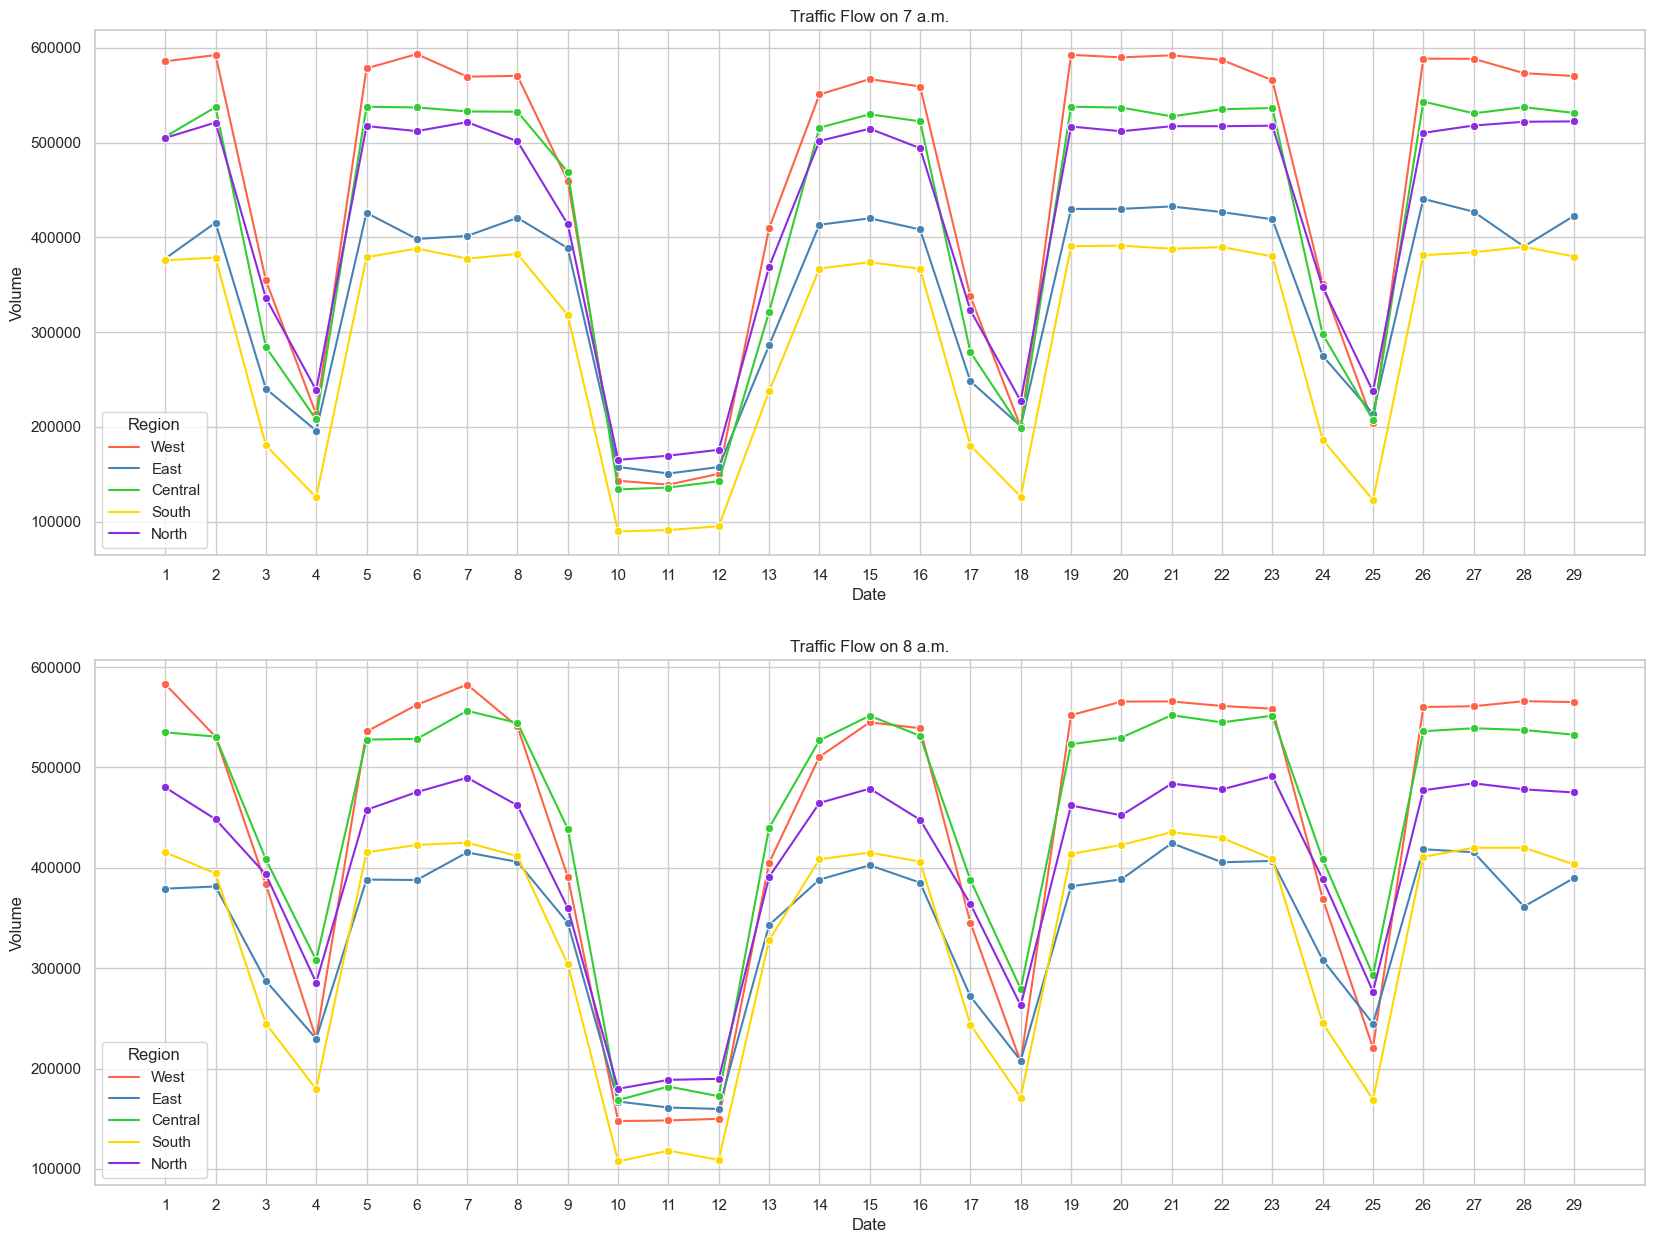

'    '

In [29]:
# merge the traffic flow data with the region data
merged_7h_group = merged_7h_df.groupby(['Region', 'Day'])['Volume'].sum().reset_index()
region_mapping = {0: 'West', 1: 'East', 2: 'Central', 3: 'South', 4: 'North'}
merged_7h_group['Region'] = merged_7h_group['Region'].map(region_mapping)


merged_8h_group = merged_8h_df.groupby(['Region', 'Day'])['Volume'].sum().reset_index()
region_mapping = {0: 'West', 1: 'East', 2: 'Central', 3: 'South', 4: 'North'}
merged_8h_group['Region'] = merged_8h_group['Region'].map(region_mapping)


sns.set(style="whitegrid")
custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700', '#8A2BE2']
# Visualization
plt.figure(figsize=(20,15))
plt.subplot(2, 1, 1)
sns.lineplot(data=merged_7h_group, x='Day', y='Volume', hue='Region', marker='o', palette=custom_palette)

plt.title('Traffic Flow on 7 a.m.')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.xticks(merged_7h_group['Day'].unique())  
plt.grid(True)

plt.subplot(2, 1, 2)
sns.lineplot(data=merged_8h_group, x='Day', y='Volume', hue='Region', marker='o', palette=custom_palette)

plt.title('Traffic Flow on 8 a.m.')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.xticks(merged_7h_group['Day'].unique())  
plt.grid(True)

plt.show()
""" """ """  """ """ """

## 4. Data Modelling and Analysis

## 4.1 Vehicle Vs. Pollution 
In this part, our goal is to build a linear regression model to study the impact of vehicle population on the national pollution level.

### 4.1.1 Different type of Vehicle Vs. Pollution

**1. Data Merging**  
The code first merges vehicle population data and pollution data based on the common column 'year'.
The merged data includes various vehicle types, their counts, and the 'national' pollution level for each year.

**2. Data Filtering and Pivoting**  
The dataset is filtered to include only relevant columns: 'year', 'type', 'Cars and Station-wagons number', 'national' (pollution level).
Then, the data is pivoted, transforming the vehicle types into columns with corresponding counts.

**3. Preparation of Independent (X) and Dependent (y) Variables** 
The independent variables (X) include the vehicle types, and the target variable (y) is the national pollution level.
This prepares the data for the regression model by defining which columns will be used to predict the national pollution level.

**4. Training and Testing Data Split**  
The data is split into training and testing sets with a 50-50 ratio (test_size=2 means half of the data is for training and the other half for testing).

**5. Linear Regression Model**  
A linear regression model is created using the LinearRegression class from the sklearn library.
The model is trained using the training data, and coefficients (for each vehicle type) are calculated to understand the relationship between vehicle counts and pollution levels.

**6. Model Results**  
Coefficients: Each vehicle type has a corresponding coefficient that indicates the degree of its impact on the national pollution level. For example:
The coefficient for Cars and Station-wagons number is negative, suggesting that an increase in the number of cars and station-wagons may be correlated with a decrease in the national pollution level, which could be counterintuitive and requires further investigation.  

Intercept: The intercept value of -1.0559340078491404 represents the base level of pollution when all independent variables are zero.
 
R-squared: The R-squared value is  -36.01709723353118, which is a poor fit, indicating that the linear regression model is not effectively predicting the national pollution level based on the current dataset and variables. This negative R-squared value suggests that the model performs worse than a simple mean prediction.

**7. Conclusion**  
We believe that the poor fit of the current linear regression model is primarily due to the scarcity of data points. With six-dimensional data, it is difficult to derive a highly generalizable linear model from only seven available data points. Another possible reason is the lack of sufficient features, as some important factors influencing the national pollution level may not be included in the dataset.

In [30]:
from sklearn.preprocessing import StandardScaler
# Merge vehicle population data and pollutant data based on the 'year' column
data_merged = pd.merge(vehicle_population_df, average_df, on='year')
data_merged.to_csv('data/data_merged.csv', index=False) 

# Filter the merged data for relevant columns: 'year', 'type', vehicle count, and 'national' pollution level
data_filtered = data_merged[['year', 'type', 'Cars and Station-wagons number', 'national']]

# Pivot the data to make each vehicle type a column (expand horizontally by vehicle type)
data_pivot = data_filtered.pivot_table(index=['year'], columns='type', values='Cars and Station-wagons number')

# Add the 'national' column back to the pivoted dataset
data_pivot['national'] = data_filtered.groupby('year')['national'].first().values
data_pivot.to_csv('data/data_pivot.csv', index=False) 

# Prepare the independent variables (X) and target variable (y)
X = data_pivot.drop(columns='national').values  
y = data_pivot['national'].values 
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Fit the model using the training data
model.fit(X_train, y_train)

# Output the model's results
print("Coefficients (per vehicle type):", model.coef_)  
print("Intercept:", model.intercept_)  
print("R-squared:", model.score(X_test, y_test)) 


Coefficients (per vehicle type): [ 1.25047315 -0.66519555  0.25888298 -0.4334553  -0.09807107  0.60075322]
Intercept: -1.0559340078491406
R-squared: -36.01709723353122


### 4.1.2 Different Category Vs Pollution
Similar to the previous section, we first pivoted the data so that each vehicle category serves as a column, and the year is used as the row index. We then filled any missing values (fillna(0)) to ensure data completeness. The independent variable (X) is the number of vehicles in each category, and the target variable (y) is the national pollution level for each year. The final R-squared value is -52.579, indicating that the model's fit to the target is still poor. This may be due to a weak linear relationship between the features and the target variable, but it could also be attributed to the insufficient number of data points.

In [31]:
merged_df = pd.merge(categoty_df, average_df, on='year', how='inner')
merged_df

,category,year,number,west,national,east,central,south,north
0,Buses,2017,18814,17.204986,19.628809,13.434903,13.490305,11.002770,15.376731
1,Cars and Station-wagons,2017,612256,17.204986,19.628809,13.434903,13.490305,11.002770,15.376731
2,Goods and Other Vehicles,2017,142857,17.204986,19.628809,13.434903,13.490305,11.002770,15.376731
3,Motorcycles and Scooters,2017,141304,17.204986,19.628809,13.434903,13.490305,11.002770,15.376731
4,Tax Exempted Vehicles,2017,23471,17.204986,19.628809,13.434903,13.490305,11.002770,15.376731
5,Taxis,2017,23140,17.204986,19.628809,13.434903,13.490305,11.002770,15.376731
6,Buses,2018,18947,14.723288,17.684932,11.254795,13.646575,12.345205,14.191781
7,Cars and Station-wagons,2018,615452,14.723288,17.684932,11.254795,13.646575,12.345205,14.191781
8,Goods and Other Vehicles,2018,141408,14.723288,17.684932,11.254795,13.646575,12.345205,14.191781
9,Motorcycles and Scooters,2018,136842,14.723288,17.684932,11.254795,13.646575,12.345205,14.191781


In [32]:
vehicle_categories = merged_df['category'].unique()
df_pivot = merged_df.pivot(index='year', columns='category', values='number').fillna(0)

# prepare the data for the model
X = df_pivot[vehicle_categories].values
y = merged_df.groupby('year')['national'].mean().values

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)

y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


test_score = model.score(X_test, y_test)

print("Test R-squared:", test_score)


Coefficients: [ 0.86048855  0.43111367  0.33784053  0.50288223  0.21970722 -0.73555269]
Intercept: -1.2968600368807368
Test R-squared: -52.57919179212208


## 4.2 Traffic Vs. Air Pollutionhat


#### 4.2.1 Aggregating Traffic Data from JSON Files
- **Objective**: The traffic data is stored in multiple JSON files, each representing traffic flow information at different times and locations. Our goal is to **combine these files into a single dataset** to enable comprehensive analysis.

In [33]:
import os
import json
from collections import defaultdict
from datetime import datetime

# folder_path = '/Users/bvnosssssv/Documents/GitHub/IS5126-Grp-hw/data/traffic_flow'
folder_path='data/traffic_flow'

traffic_list=[]

for filename in os.listdir(folder_path):
    if filename.endswith('.json'):
        file_path = os.path.join(folder_path, filename)

        with open(file_path, 'r') as f:
            data = json.load(f)
        value_data = data['value']
        last_updated_time = data['lastUpdatedTime']

        df = pd.DataFrame(value_data)
        df['lastUpdatedTime'] = last_updated_time
        traffic_list.append(df)

final_traffic = pd.concat(traffic_list, ignore_index=True)
final_traffic


,LinkID,RoadName,RoadCategory,SpeedBand,MinimumSpeed,MaximumSpeed,StartLon,StartLat,EndLon,EndLat,lastUpdatedTime
0,103000000,KENT ROAD,E,3,20,29,103.85298052044503,1.3170142376560023,103.85259882242372,1.3166840028663076,2024-10-06 09:35:00
1,103000010,BUCKLEY ROAD,E,8,70,999,103.84102305136321,1.3166507852203482,103.84022564204443,1.316912438354752,2024-10-06 09:35:00
2,103000011,BUCKLEY ROAD,E,8,70,999,103.84022564204443,1.316912438354752,103.84102305136321,1.3166507852203482,2024-10-06 09:35:00
3,103000014,SHREWSBURY ROAD,E,5,40,49,103.84700267615683,1.3186726294030418,103.84711392225329,1.3180212058893457,2024-10-06 09:35:00
4,103000015,SHREWSBURY ROAD,E,5,40,49,103.84711392225329,1.3180212058893457,103.84700267615683,1.3186726294030418,2024-10-06 09:35:00
...,...,...,...,...,...,...,...,...,...,...,...
273495,103001218,DRAYCOTT DRIVE,D,3,20,29,103.83110989321554,1.3096279339357806,103.83119447352243,1.309694857000047,2024-10-04 20:55:00
273496,103001219,DRAYCOTT DRIVE,D,4,30,39,103.83119447352243,1.309694857000047,103.83110989321554,1.3096279339357806,2024-10-04 20:55:00
273497,103001226,PADANG JERINGAU,D,4,30,39,103.86554520014256,1.3099051585628567,103.86611733337693,1.309253800591554,2024-10-04 20:55:00
273498,103001227,PADANG JERINGAU,D,4,30,39,103.86611733337693,1.309253800591554,103.86554520014256,1.3099051585628567,2024-10-04 20:55:00


### 4.2.2 Converting 'lastUpdatedTime' to Datetime Format
To facilitate time-based analysis of traffic flow data, we convert the `lastUpdatedTime` column to a **datetime object**.

In [34]:
final_traffic['lastUpdatedTime'] = final_traffic['lastUpdatedTime'].apply(lambda x: datetime.fromisoformat(x))

In [35]:
# folder_path = '/Users/bvnosssssv/Documents/GitHub/IS5126-Grp-hw/data/pt'
folder_path='data/pt'

pt_list=[]

for filename in os.listdir(folder_path):
    if filename.endswith('.json'):
        file_path = os.path.join(folder_path, filename)

        with open(file_path, 'r') as f:
            data = json.load(f)['data']['items'][0]
        value_data = data['readings']
        last_updated_time = data['updatedTimestamp']

        df = pd.DataFrame(value_data).reset_index(names='region')
        df['lastUpdatedTime'] = datetime.fromisoformat(last_updated_time).replace(second=0, microsecond=0)
        pt_list.append(df)

final_pt = pd.concat(pt_list, ignore_index=True)
final_pt

,region,o3_sub_index,no2_one_hour_max,o3_eight_hour_max,psi_twenty_four_hourly,pm10_twenty_four_hourly,pm10_sub_index,pm25_twenty_four_hourly,so2_sub_index,pm25_sub_index,so2_twenty_four_hourly,co_eight_hour_max,co_sub_index,lastUpdatedTime
0,west,6,32,13,60,28,28,20,5,60,7,0,5,2024-10-05 01:30:00+08:00
1,east,12,41,27,52,34,34,13,3,52,4,1,6,2024-10-05 01:30:00+08:00
2,central,10,62,23,62,38,38,22,2,62,4,1,5,2024-10-05 01:30:00+08:00
3,south,5,21,13,54,24,24,15,3,54,5,0,4,2024-10-05 01:30:00+08:00
4,north,6,41,15,56,31,31,17,1,56,2,1,11,2024-10-05 01:30:00+08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,west,4,12,8,53,22,22,14,5,53,7,1,6,2024-10-05 11:45:00+08:00
496,east,4,31,9,45,29,29,11,4,45,7,1,8,2024-10-05 11:45:00+08:00
497,central,5,28,12,58,33,33,18,3,58,4,1,6,2024-10-05 11:45:00+08:00
498,south,2,21,4,53,20,20,14,4,53,6,0,5,2024-10-05 11:45:00+08:00


### 4.2.3 Data Preparation: Categorizing Traffic Data by Region
To analyze the relationship between traffic and air pollution, we first need to ensure both datasets are comparable in terms of geographical categorization.

- **Air Pollution Data**: The air pollution dataset is sorted by five regions—**West**, **East**, **Central**, **North**, and **South**.
- **Traffic Data**: The traffic dataset provides **longitude and latitude** coordinates for each road segment.

To enable an accurate comparison between these two datasets:
- We need to categorize the **traffic data** into the **same five regions** as the pollution data.
- This involves assigning each road segment to one of the regions based on its longitude and latitude.

The categorization will allow us to analyze pollution levels in each region and assess how **traffic congestion** or **vehicle distribution** correlates with **air quality** in that area.

In [36]:
# center for regions
for filename in os.listdir(folder_path):
    if filename.endswith('.json'):
        file_path = os.path.join(folder_path, filename)

        with open(file_path, 'r') as f:
            data = json.load(f)['data']['regionMetadata']
            data2 = [(item['name'], item['labelLocation']['latitude'], item['labelLocation']['longitude']) for item in data]

    break
center_df = pd.DataFrame(data2, columns=['region', 'latitude', 'longitude'])
center_df

,region,latitude,longitude
0,west,1.35735,103.70
1,east,1.35735,103.94
2,central,1.35735,103.82
3,south,1.29587,103.82
4,north,1.41803,103.82


In [37]:
final_pt.columns

Index(['region', 'o3_sub_index', 'no2_one_hour_max', 'o3_eight_hour_max',
       'psi_twenty_four_hourly', 'pm10_twenty_four_hourly', 'pm10_sub_index',
       'pm25_twenty_four_hourly', 'so2_sub_index', 'pm25_sub_index',
       'so2_twenty_four_hourly', 'co_eight_hour_max', 'co_sub_index',
       'lastUpdatedTime'],
      dtype='object')

In [38]:
final_traffic_labeled = final_traffic[['LinkID', 'StartLon', 'StartLat', 'EndLon', 'EndLat']]

final_traffic_labeled['StartLon'] = pd.to_numeric(final_traffic_labeled['StartLon'], errors='coerce')
final_traffic_labeled['EndLon'] = pd.to_numeric(final_traffic_labeled['EndLon'], errors='coerce')
final_traffic_labeled['StartLat'] = pd.to_numeric(final_traffic_labeled['StartLat'], errors='coerce')
final_traffic_labeled['EndLat'] = pd.to_numeric(final_traffic_labeled['EndLat'], errors='coerce')

final_traffic_labeled['Longitude'] = (final_traffic_labeled['StartLon'] + final_traffic_labeled['EndLon']) / 2
final_traffic_labeled['Latitude'] = (final_traffic_labeled['StartLat'] + final_traffic_labeled['EndLat']) / 2

final_traffic_labeled.drop_duplicates(inplace=True)

final_traffic# final_traffic.to_csv("final_traffic.csv")
# final_pt.to_csv("final_pt.csv")
# center_df.to_csv("center_df.csv")
# final_traffic_labeled.to_csv('final_traffic_labeled.csv')

/var/folders/l7/d0lb4fb15qx7kr983gqvzs2c0000gn/T/ipykernel_3506/656101935.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_traffic_labeled['StartLon'] = pd.to_numeric(final_traffic_labeled['StartLon'], errors='coerce')
/var/folders/l7/d0lb4fb15qx7kr983gqvzs2c0000gn/T/ipykernel_3506/656101935.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_traffic_labeled['EndLon'] = pd.to_numeric(final_traffic_labeled['EndLon'], errors='coerce')
/var/folders/l7/d0lb4fb15qx7kr983gqvzs2c0000gn/T/ipykernel_3

,LinkID,RoadName,RoadCategory,SpeedBand,MinimumSpeed,MaximumSpeed,StartLon,StartLat,EndLon,EndLat,lastUpdatedTime
0,103000000,KENT ROAD,E,3,20,29,103.85298052044503,1.3170142376560023,103.85259882242372,1.3166840028663076,2024-10-06 09:35:00
1,103000010,BUCKLEY ROAD,E,8,70,999,103.84102305136321,1.3166507852203482,103.84022564204443,1.316912438354752,2024-10-06 09:35:00
2,103000011,BUCKLEY ROAD,E,8,70,999,103.84022564204443,1.316912438354752,103.84102305136321,1.3166507852203482,2024-10-06 09:35:00
3,103000014,SHREWSBURY ROAD,E,5,40,49,103.84700267615683,1.3186726294030418,103.84711392225329,1.3180212058893457,2024-10-06 09:35:00
4,103000015,SHREWSBURY ROAD,E,5,40,49,103.84711392225329,1.3180212058893457,103.84700267615683,1.3186726294030418,2024-10-06 09:35:00
...,...,...,...,...,...,...,...,...,...,...,...
273495,103001218,DRAYCOTT DRIVE,D,3,20,29,103.83110989321554,1.3096279339357806,103.83119447352243,1.309694857000047,2024-10-04 20:55:00
273496,103001219,DRAYCOTT DRIVE,D,4,30,39,103.83119447352243,1.309694857000047,103.83110989321554,1.3096279339357806,2024-10-04 20:55:00
273497,103001226,PADANG JERINGAU,D,4,30,39,103.86554520014256,1.3099051585628567,103.86611733337693,1.309253800591554,2024-10-04 20:55:00
273498,103001227,PADANG JERINGAU,D,4,30,39,103.86611733337693,1.309253800591554,103.86554520014256,1.3099051585628567,2024-10-04 20:55:00


In [39]:
region_mapping = {
    0: 'west',
    1: 'east',
    2: 'central',
    3: 'south',
    4: 'north'
}

final_traffic_labeled['region'] = final_traffic_labeled['region'].replace(region_mapping)
final_traffic=pd.merge(final_traffic, final_traffic_labeled[['LinkID','Longitude', 'Latitude','region']], on='LinkID', how='left')

KeyError: 'region'

In [ ]:
final_traffic.columns

### 4.2.4 Removing Timezone Information from 'lastUpdatedTime'
To ensure consistency in datetime formats across different datasets, we remove any timezone information from the `lastUpdatedTime` column in both `final_traffic` and `final_pt` DataFrames.

- **Why Remove Timezone Information?**
  - **Uniformity**: Removing timezone information helps standardize the datetime format across datasets, ensuring compatibility when merging or comparing them.
  - **Simplified Analysis**: Timezone differences can introduce complexity, especially when working with data collected from different regions. Removing the timezone makes temporal analysis simpler and more straightforward.

- **Implementation**:
  - We use `pd.to_datetime()` to convert `lastUpdatedTime` to a datetime format.
  - `.dt.tz_localize(None)` is used to remove any timezone information from the column.

This step is essential to avoid discrepancies in time-related data during further analysis and merging processes.


In [40]:
# drop unnecessary columns
final_traffic['lastUpdatedTime'] = pd.to_datetime(final_traffic['lastUpdatedTime']).dt.tz_localize(None)
final_pt['lastUpdatedTime'] = pd.to_datetime(final_pt['lastUpdatedTime']).dt.tz_localize(None)

In [ ]:
final_traffic_groupbyregion=final_traffic.groupby(['region','lastUpdatedTime'])['SpeedBand'].mean().reset_index()
final_traffic_groupbyregion

In [ ]:
# merge traffic and pt data
traffic_pt = pd.merge(final_traffic_groupbyregion, final_pt, on=['lastUpdatedTime', 'region'], how='inner')
traffic_pt.iloc[:,0:15]

### 4.2.5 Linear Regression Analysis: SpeedBand vs. Air Pollution Indicators

In this section, we conduct a series of **linear regression analyses** to determine the relationship between **traffic speed (SpeedBand)** and various **air quality indicators**. The aim is to assess whether variations in traffic speed have any significant impact on different pollutants.
- We use `LinearRegression` from `sklearn.linear_model` to fit linear models for each pollution indicator.


#### 4.2.6 Visualization: Regression Results
- **Subplots**:
  - We create subplots using `matplotlib` to display **scatter plots** and **regression lines** for each pollution indicator.
  - Each subplot shows how **SpeedBand** correlates with the respective pollution indicator (`y`).
  - The `sns.regplot()` function from **Seaborn** is used to plot the **linear regression line**, providing a visual representation of the relationship.
  - **Regions are also indicated** on the scatter plots using colors to understand regional variations in the relationship between traffic speed and air quality.

- **Figure Layout**:
  - A **4x3 grid of subplots** is created, allowing visualization of all pollution indicators in a single figure.
  - The layout is adjusted with `plt.tight_layout()` to ensure that plots are well spaced.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


y_vars = [
    'o3_sub_index', 'no2_one_hour_max', 'o3_eight_hour_max', 'psi_twenty_four_hourly',
    'pm10_twenty_four_hourly', 'pm10_sub_index', 'pm25_twenty_four_hourly',
    'so2_sub_index', 'pm25_sub_index', 'so2_twenty_four_hourly',
    'co_eight_hour_max', 'co_sub_index'
]

r2_values = {}

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 18))
axes = axes.flatten()


for i, y in enumerate(y_vars):
    X = traffic_pt[['SpeedBand']]
    y_data = traffic_pt[y]

    # linear regression model
    model = LinearRegression()
    model.fit(X, y_data)

    # predict y
    y_pred = model.predict(X)

    # calculate R²
    r2 = r2_score(y_data, y_pred)
    r2_values[y] = r2  

    sns.regplot(
        x='SpeedBand', y=y, data=traffic_pt, ax=axes[i], scatter_kws={'alpha':0.5}
    )

    axes[i].set_title(f"SpeedBand vs {y}")
    sns.scatterplot(x='SpeedBand', y=y, hue='region', data=traffic_pt, ax=axes[i], legend=False)


plt.tight_layout()
plt.show()

for var, r2 in r2_values.items():
    print(f"{var}: R² = {r2:.2f}")

### 4.2.7 Results of Linear Regression: SpeedBand vs. Air Quality Indicators

#### 4.2.7.1 Overview of Findings
We conducted linear regression analyses to assess the relationship between **traffic speed (SpeedBand)** and various **air pollution indicators**. The scatter plots and **R² values** for each pollutant are presented to evaluate the strength of these relationships.

#### 4.2.7.2 Analysis of Plots and R² Values

- **General Trends**:
  - In most cases, the **R² values are quite low**, indicating that **SpeedBand** is not a strong predictor of many of the air quality indicators.
  - The visual scatter plots reveal that the data points are widely scattered, and the regression lines often do not show a clear trend, indicating weak correlations between traffic speed and pollutant levels.

- **Key Observations for Each Pollutant**:

  1. **`o3_sub_index`**:
     - **R² = 0.02**: A very low R², indicating no meaningful correlation between traffic speed and ozone sub-index levels.
     - The scatter plot shows no clear trend between `SpeedBand` and `o3_sub_index`.

  2. **`no2_one_hour_max`**:
     - **R² = 0.18**: Some moderate correlation, suggesting that nitrogen dioxide levels might be somewhat influenced by traffic speed.
     - The plot shows a slight positive trend, implying higher `SpeedBand` may be linked to higher NO₂ concentrations.

  3. **`o3_eight_hour_max`**:
     - **R² = 0.02**: Similar to the ozone sub-index, a very low R² value indicates minimal correlation between `SpeedBand` and `o3_eight_hour_max`.

  4. **`psi_twenty_four_hourly`**:
     - **R² = 0.29**: Shows a modest correlation between `SpeedBand` and the PSI index, suggesting that traffic speed might play some role in affecting the Pollutant Standards Index.
     - The regression line suggests a weak positive relationship.

  5. **`pm10_twenty_four_hourly`**:
     - **R² = 0.44**: One of the higher R² values, indicating a stronger positive correlation between `SpeedBand` and PM₁₀ levels.
     - The plot shows a positive trend, implying that as traffic speed increases, PM₁₀ concentrations tend to increase as well.

  6. **`pm10_sub_index`**:
     - **R² = 0.42**: Similar to `pm10_twenty_four_hourly`, indicating a moderate positive correlation.
     - The plot suggests that PM₁₀ levels are influenced by changes in traffic speed.

  7. **`pm25_twenty_four_hourly`**:
     - **R² = 0.50**: The highest R² value, indicating that **SpeedBand** can explain about half of the variance in PM₂.₅ levels.
     - The plot shows a significant positive trend, implying that increased traffic speed may lead to increased PM₂.₅ levels.

  8. **`so2_sub_index`**:
     - **R² = 0.04**: Indicates a very weak relationship between traffic speed and SO₂ levels.

  9. **`so2_twenty_four_hourly`**:
     - **R² = 0.04**: Similar to `so2_sub_index`, indicating that traffic speed does not significantly impact SO₂ concentrations.

  10. **`co_eight_hour_max`**:
      - **R² = 0.00**: No correlation at all between `SpeedBand` and CO levels.
      - The scatter plot shows a flat line, indicating that changes in traffic speed do not influence CO concentrations.

  11. **`co_sub_index`**:
      - **R² = 0.01**: Similar to `co_eight_hour_max`, suggesting no significant relationship.

#### 4.2.7.3 Potential Explanations for the Observations

- **Weak Relationships (Low R² Values)**:
  - Many pollutants, such as **ozone (O₃)** and **carbon monoxide (CO)**, showed little to no correlation with `SpeedBand`.
  - This suggests that **traffic speed alone** is not a sufficient indicator of these pollutants. Other factors, such as **vehicle type**, **fuel type**, **industrial emissions**, or **meteorological conditions**, likely play a larger role in determining these pollution levels.

- **Moderate to Strong Relationships**:
  - **Particulate Matter (PM₁₀ and PM₂.₅)** showed a stronger correlation with `SpeedBand` compared to other pollutants.
  - This could be due to **turbulence** caused by vehicles moving at higher speeds, which may **re-suspend road dust** and contribute to higher levels of particulate matter.
  - **Traffic density** and the presence of **heavy-duty vehicles** may also contribute to these higher particulate levels when traffic speeds increase.

- **Regional Differences**:
  - The scatter plots use colors to indicate different regions, and some regions seem to exhibit stronger relationships than others.
  - This suggests that **regional factors**, such as **urbanization level**, **road conditions**, and **local emission sources**, may be influencing the relationships observed in the data.


### 4.2.8 Conclusion (Traffic & Air Pollution in Singapore)
- The results indicate that **SpeedBand** has a significant correlation with **particulate matter** levels but is not a strong predictor for most other air quality indicators.

## 5. Comparative Analysis

In [ ]:
laqn_df = pd.read_csv('data/london/LaqnData.csv')
laqn_df

In [40]:
laqn_df.info()

NameError: name 'laqn_df' is not defined

#### 5.1 Overview of London Dataset
- The dataset contains **11,684 records** of air pollution measurements in **London** from **2015 to 2022**.
- Columns include:
  - **Site** (location of monitoring station)
  - **Species** (pollutant type, e.g., `NO`, `PM10`)
  - **ReadingDateTime**, **Value** (pollution concentration), **Units**, and **Provisional or Ratified**.

#### 5.2 Key Differences Compared to Singapore Data
- **Timeframe**: London data spans a **longer period** (2015-2022), while Singapore data focuses on a **specific timeframe** and **yearly data**.
- **Granularity**: London data includes specific **site locations**, whereas Singapore data is categorized by **regions**.

In [41]:
print(laqn_df['Site'].unique())
print(laqn_df['Provisional or Ratified'].unique())
laqn_df.drop(columns=['Site', 'Provisional or Ratified'], inplace=True)
laqn_df['year'] = pd.to_datetime(laqn_df['ReadingDateTime'], format='%d/%m/%Y %H:%M').dt.year
laqn_df['Value'] = pd.to_numeric(laqn_df['Value'], errors='coerce')
laqn_df['Value'] = laqn_df.groupby('Species')['Value'].transform(lambda x: x.fillna(x.median()))
laqn_df

NameError: name 'laqn_df' is not defined

### 5.3 Boxplot Analysis of Pollutant Levels by Species

- **Boxplot Overview**:
  - The boxplot shows the distribution of pollutant values (`Value`) for different species (`NO`, `NO2`, `NOX`, `PM10`) in London.
  - Each box represents the **interquartile range (IQR)**, with whiskers showing the spread of the data, and individual points representing **outliers**.


In [42]:
# plot boxplot
plt.figure(figsize=(10, 6))
laqn_df.boxplot(column='Value', by='Species', grid=False)
plt.title('Boxplot of Values by Species')
plt.suptitle('')  
plt.xlabel('Species')
plt.ylabel('Value')
plt.show()

NameError: name 'laqn_df' is not defined

<Figure size 1000x600 with 0 Axes>

### 5.3.1 **Key Observations**
  - **NOX** shows the **highest variability** and contains many outliers, indicating frequent episodes of elevated NOX levels.
  - **NO2** and **PM10** have relatively smaller ranges and fewer outliers compared to **NO** and **NOX**.
  - **PM10** has the lowest median value, suggesting that **particulate matter** levels are typically lower than gaseous pollutants.


----
### 5.4 Analysis: Traffic Volume vs. Pollutant Levels

#### 5.4.1 Overview
- We analyzed the **relationship between traffic volume** and average pollutant levels (`NO`, `NO2`, `NOX`, `PM10`) in London from **2015 to 2022**.
- The dataset was grouped by **year** and **Species** to calculate the **annual average pollutant values**. Traffic volume data was then mapped to the corresponding years.

In [43]:
laqn_avg_df = laqn_df.groupby(['year', 'Species'])['Value'].mean().reset_index()

london_tf_volumn = [31624, 32321, 32276, 32175, 32612, 26737, 29698, 30721]
years = sorted(laqn_avg_df['year'].unique())

# add traffic volume to the data frame
laqn_avg_df['TrafficVolume'] = laqn_avg_df['year'].map(dict(zip(years, london_tf_volumn)))

species_list = laqn_avg_df['Species'].unique()


plt.figure(figsize=(12, 6))


for species in species_list:
    species_data = laqn_avg_df[laqn_avg_df['Species'] == species]
    
    X = species_data['TrafficVolume'].values.reshape(-1, 1)
    y = species_data['Value'].values
    
    # linear regression model
    model = LinearRegression()
    model.fit(X, y)
    
    
    y_pred = model.predict(X)
    
    r2 = r2_score(y, y_pred)
    print(f'R² for {species}: {r2:.2f}')
    
    plt.scatter(X, y, label=f'{species} Data', alpha=0.6)
    plt.plot(X, y_pred, label=f'{species} Fit', linestyle='--')

plt.title('Relationship between Traffic Volume and Species Values')
plt.xlabel('Traffic Volume')
plt.ylabel('Average Value')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'laqn_df' is not defined

#### 5.4.2 Key Findings
- **R² Values**:
  - **NO**: **R² = 0.37** - Indicates a moderate correlation between traffic volume and NO levels.
  - **NO2**: **R² = 0.63** - Stronger correlation, suggesting that NO2 levels are significantly influenced by traffic.
  - **NOX**: **R² = 0.42** - Moderate correlation, indicating that traffic affects NOX levels.
  - **PM10**: **R² = 0.43** - Indicates a moderate relationship with traffic volume.
  
- **Interpretation**:
  - **NO2** has the **strongest correlation** with traffic volume, suggesting it is highly affected by vehicle emissions.
  - **NO, NOX, and PM10** show moderate correlations, implying that while traffic is a factor, other factors (e.g., weather, industrial emissions) likely influence pollutant levels.

#### 5.4.3 Visual Insights
- The scatter plots for each pollutant show data points along with fitted regression lines.
- **NO2** shows a clear upward trend with increasing traffic volume, while others show less pronounced trends.
- Understanding these relationships is crucial for evaluating **traffic control measures** to mitigate air pollution.

This analysis provides evidence that **traffic volume** impacts **NO2** levels most significantly among the pollutants, suggesting targeted traffic policies could reduce NO2 concentrations in urban areas.

## 6. Conclusions and Recommendations

#### 6.1 Summary of Key Findings
This study analyzed air quality data from **London** and **Singapore** to explore the relationship between **traffic conditions** and **air pollution**. We examined multiple pollutant types, including **NO**, **NO2**, **NOX**, and **PM10**, across both cities, using historical datasets, boxplots, regression models, and comparative visualizations. The key findings from the analysis can be summarized as follows:

- **London Air Quality Dataset**:
  - The **London dataset** spanned a long period, from **2015 to 2022**, covering a wide range of pollutants, including **NO, NO2, NOX**, and **PM10**.
  - Boxplots revealed significant variability, with **NOX** showing the most pronounced fluctuations and numerous outliers, indicating high levels of **peak pollution episodes**.

- **Singapore Air Quality and Traffic Data**:
  - The **Singapore dataset** included multiple pollutants and was analyzed alongside **traffic speed bands** (`SpeedBand`). 
  - Our regression analysis found that **particulate matter (PM10 and PM2.5)** was moderately correlated with traffic speed, suggesting a link between **traffic conditions** and the amount of particulate pollution in Singapore.

- **Comparative Analysis of Traffic and Pollution**:
  - Using the London dataset, we explored the relationship between **traffic volume** and pollutant levels for the key species (`NO`, `NO2`, `NOX`, `PM10`).
  - **NO2** was found to have the strongest relationship with traffic volume (**R² = 0.63**), suggesting that **vehicle emissions** play a significant role in determining NO2 concentrations.
  - Other pollutants (`NO`, `NOX`, and `PM10`) showed moderate correlations, indicating that while traffic contributes to their levels, **additional factors** such as industrial emissions or meteorological influences are also at play.

#### 6.2 Key Insights

- **Impact of Traffic on Pollution**:
  - The analysis indicates that **traffic conditions**, specifically **traffic speed** and **volume**, have a significant impact on air pollutant levels, particularly for **nitrogen dioxide (NO2)** and **particulate matter (PM10, PM2.5)**.
  - **Higher traffic volumes** and **lower traffic speeds** correlate with increased pollutant levels, highlighting the role of congestion and traffic density in exacerbating air pollution.

- **Regional Differences**:
  - The variability in pollutant levels across different monitoring sites in **London** compared to **regional divisions** in Singapore suggests that **local factors**, such as **urbanization**, **road network design**, and **traffic control measures**, can significantly influence air quality.
  - **London** data showed higher peak values and more pronounced outliers for pollutants like **NOX**, likely due to London's historical reliance on fossil fuels and industrial activity.

- **Strength of Correlation**:
  - The **strong correlation** between **traffic volume** and **NO2** levels in London implies that NO2 emissions are largely traffic-related. Similar patterns were observed in Singapore, where **PM10** and **PM2.5** also showed moderate correlations with traffic speed.

#### 6.3 Recommendations

Based on the findings, we propose several strategies and policy recommendations to mitigate air pollution in urban areas:

##### 6.3.1 Traffic Management Measures
- **Reduce Congestion**:
  - The results suggest that **traffic congestion** is a major contributor to elevated pollutant levels. Implementing **congestion pricing** or **low-emission zones** can help to reduce the volume of vehicles in high-density areas, thereby decreasing pollutant concentrations.
  - Encourage **public transport use** and **carpooling** to reduce the number of vehicles on the road, which in turn can reduce NO2 and particulate emissions.

- **Optimize Traffic Flow**:
  - To address the correlation between **traffic speed** and pollutant levels, cities like Singapore could benefit from **smart traffic management systems** that maintain smoother traffic flow and reduce stop-and-go conditions.
  - Implementing **adaptive traffic signals** that optimize traffic flow based on real-time data could help reduce emissions from idling vehicles.

##### 6.3.2 Promotion of Clean Energy Vehicles
- **Transition to Electric Vehicles (EVs)**:
  - Given the significant contribution of **traffic emissions** to air pollution, promoting the use of **electric vehicles** (EVs) can help reduce emissions of pollutants like **NO2** and **NOX**.
  - Governments should offer **incentives** such as **subsidies** or **tax reductions** to encourage the purchase of EVs. Expanding **charging infrastructure** is also essential for large-scale adoption.

##### 6.3.3 Targeted Pollution Control Policies
- **Focus on High-Pollution Areas**:
  - The London dataset indicated that certain monitoring sites experienced frequent high pollution episodes, especially for **NOX**. Policies should be targeted in these specific areas to address the root causes of elevated emissions.
  - **Localized monitoring** should be used to identify hot spots, and actions such as **roadside vegetation** or **barriers** could be considered to limit pollutant dispersion into nearby neighborhoods.

##### 6.3.4 Public Awareness and Engagement
- **Raise Awareness on Health Impacts**:
  - Educate the public on the health impacts of **traffic-related air pollution**, particularly **NO2** and **particulate matter**, which have been shown to have significant effects on **respiratory** and **cardiovascular health**.
  - Encourage practices that reduce individual contributions to air pollution, such as **walking**, **cycling**, or opting for **public transport** for short commutes.

##### 6.3.5 Data-Driven Approaches for Continuous Improvement
- **Enhanced Monitoring**:
  - Invest in **more granular air quality monitoring** to capture real-time data across different urban locations. This data can be used to further understand pollution patterns and inform traffic policy adjustments.
  - Expand the number of monitoring sites in areas with less data coverage to provide a more comprehensive view of city-wide air quality.

- **Leverage Machine Learning for Predictive Analysis**:
  - Utilize **machine learning models** to predict pollution levels based on traffic data, weather, and other factors. Such predictive models can help preempt high pollution episodes and prompt timely interventions.

#### 6.4 Future Research Directions
- **Multi-Factor Analysis**:
  - Future studies should incorporate **additional variables** such as **industrial emissions**, **weather conditions**, and **seasonality** to build a more complete picture of the factors influencing air pollution in urban areas.
  - Incorporating **meteorological data** such as **wind speed** and **humidity** can help understand how weather affects the dispersion and concentration of pollutants.

- **Longitudinal Comparisons**:
  - Conducting **longitudinal studies** to observe the impact of implemented policies over time will provide insights into which measures are most effective in reducing air pollution levels.
  - Comparative studies between more cities (e.g., London, Singapore, and cities in other regions) could identify common successful approaches and factors unique to each city's context.

#### 6.5 Conclusion
This analysis highlights the critical role that **traffic conditions** play in influencing air quality in urban environments. Both **Singapore** and **London** show that pollutants like **NO2** and **PM** are significantly impacted by traffic volume and speed. The findings stress the importance of implementing **traffic management measures**, **promoting clean energy vehicles**, and **targeting localized interventions** to improve urban air quality.

With effective policies and public engagement, cities can mitigate the impact of traffic on air pollution, ultimately leading to improved **public health** and **environmental quality**.


## 7. References

**API used:**
- https://datamall2.mytransport.sg/ltaodataservice/v3/TrafficSpeedBands
  - AccountKey: l9hZP/8WSwKzxAogbnA++w==
- https://api-open.data.gov.sg/v2/real-time/api/psi?

**Additional Data Source:**

London-traffic-flow: https://www.gov.uk/government/collections/road-traffic-statistics

Other related files please refer to the '*data/*' folder.